<a href="https://colab.research.google.com/github/DrRanjani/Nutritional-Analysis-of-Junk-Food-A-Data-Analytics-Study-/blob/main/Final_Project_Python_for_DA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Nutritional Analysis of Junk Food: A Data Analytics Study**

#**Domain**:Healthcare

#**Objectives**




* To analyze nutritional data of junk food items across different shops
* To understand product distribution by category (Veg/Non-Veg)food
* To compare nutritional values across shops and product categories  
* To identify patterns and variations in nutritional attributes among       products
*  To examine the distribution of nutritional values across product types
* To perform comparative analysis of nutritional content between shop














#__Dataset Information__

**Source** : Open Data Portal (OpenIntro Data Repository)

**Organization** : OpenIntro (Educational Organization)

**Year / Timeline:** : General(Not Time-bound)

#**Stage 1**

**Problem Definition and Dataset Selection**

#**Problem Definition**

Junk food consumption is increasing rapidly, but its nutritional composition varies across food items and restaurants. High levels of calories, fats, sugar, and sodium can negatively impact health. There is a need to analyze junk food nutritional data to understand unhealthy patterns and identify key nutritional factors affecting food quality.

**Importing Libraries**

In [ ]:
import pandas as pd #Importing pandas for data manipulation and analysis
import numpy as np  #Importing numpy for numerical operations
import matplotlib.pyplot as plt  #Importing matplotlib for data visualization
import seaborn as sns  # Importing seaborn for advanced statistical visualizations
import re  # Importing re for regular expressions for text processing


**Loading the Dataset from github**

In [ ]:
url="https://raw.githubusercontent.com/DrRanjani/Nutritional-Analysis-of-Junk-Food-A-Data-Analytics-Study-/main/fastfood.csv"
df=pd.read_csv(url)
df


,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
0,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2.0,0.0,95,1110,44,3.0,11,37.0,4.0,20.0,20.0,Other
1,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17.0,1.5,130,1580,62,2.0,18,46.0,6.0,20.0,20.0,Other
2,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27.0,3.0,220,1920,63,3.0,18,70.0,10.0,20.0,50.0,Other
3,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10.0,0.5,155,1940,62,2.0,18,55.0,6.0,25.0,20.0,Other
4,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12.0,0.5,120,1980,81,4.0,18,46.0,6.0,20.0,20.0,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,Taco Bell,Spicy Triple Double Crunchwrap,780,340,38,10.0,0.5,50,1850,87,9.0,8,23.0,20.0,10.0,25.0,Other
511,Taco Bell,Express Taco Salad w/ Chips,580,260,29,9.0,1.0,60,1270,59,8.0,7,23.0,NaN,NaN,NaN,Other
512,Taco Bell,Fiesta Taco Salad-Beef,780,380,42,10.0,1.0,60,1340,74,11.0,7,26.0,NaN,NaN,NaN,Other
513,Taco Bell,Fiesta Taco Salad-Chicken,720,320,35,7.0,0.0,70,1260,70,8.0,8,32.0,NaN,NaN,NaN,Other


#Dataset Desceription

In [ ]:
df.head() # Displaying first 5 rows of the dataset


,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
0,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2.0,0.0,95,1110,44,3.0,11,37.0,4.0,20.0,20.0,Other
1,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17.0,1.5,130,1580,62,2.0,18,46.0,6.0,20.0,20.0,Other
2,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27.0,3.0,220,1920,63,3.0,18,70.0,10.0,20.0,50.0,Other
3,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10.0,0.5,155,1940,62,2.0,18,55.0,6.0,25.0,20.0,Other
4,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12.0,0.5,120,1980,81,4.0,18,46.0,6.0,20.0,20.0,Other


In [ ]:
df.info()   # Displaying dataset structure and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   restaurant   515 non-null    object 
 1   item         515 non-null    object 
 2   calories     515 non-null    int64  
 3   cal_fat      515 non-null    int64  
 4   total_fat    515 non-null    int64  
 5   sat_fat      515 non-null    float64
 6   trans_fat    515 non-null    float64
 7   cholesterol  515 non-null    int64  
 8   sodium       515 non-null    int64  
 9   total_carb   515 non-null    int64  
 10  fiber        503 non-null    float64
 11  sugar        515 non-null    int64  
 12  protein      514 non-null    float64
 13  vit_a        301 non-null    float64
 14  vit_c        305 non-null    float64
 15  calcium      305 non-null    float64
 16  salad        515 non-null    object 
dtypes: float64(7), int64(7), object(3)
memory usage: 68.5+ KB


In [ ]:
df.describe()  # Displaying statistical summary of numerical columns

,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium
count,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,503.000000,515.000000,514.000000,301.000000,305.000000,305.000000
mean,530.912621,238.813592,26.590291,8.153398,0.465049,72.456311,1246.737864,45.664078,4.137177,7.262136,27.891051,18.857143,20.170492,24.852459
std,282.436147,166.407510,18.411876,6.418811,0.839644,63.160406,689.954278,24.883342,3.037460,6.761301,17.683921,31.384330,30.592243,25.522073
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,330.000000,120.000000,14.000000,4.000000,0.000000,35.000000,800.000000,28.500000,2.000000,3.000000,16.000000,4.000000,4.000000,8.000000
50%,490.000000,210.000000,23.000000,7.000000,0.000000,60.000000,1110.000000,44.000000,3.000000,6.000000,24.500000,10.000000,10.000000,20.000000
75%,690.000000,310.000000,35.000000,11.000000,1.000000,95.000000,1550.000000,57.000000,5.000000,9.000000,36.000000,20.000000,30.000000,30.000000
max,2430.000000,1270.000000,141.000000,47.000000,8.000000,805.000000,6080.000000,156.000000,17.000000,87.000000,186.000000,180.000000,400.000000,290.000000


In [ ]:
df.shape  # Checking number of rows and columns

(515, 17)

In [ ]:
df.dtypes

,0
restaurant,object
item,object
calories,int64
cal_fat,int64
total_fat,int64
sat_fat,float64
trans_fat,float64
cholesterol,int64
sodium,int64
total_carb,int64


In [ ]:
df.isnull().sum()  # Checking for missing (null) values in each column


,0
restaurant,0
item,0
calories,0
cal_fat,0
total_fat,0
sat_fat,0
trans_fat,0
cholesterol,0
sodium,0
total_carb,0


In [ ]:
df.duplicated().sum()  # Checking for duplicate records in the dataset


np.int64(2)

#**Stage 2**

**Data Cleaning and Pre-processing**

**Dropping dupicate values**

In [ ]:
df.drop_duplicates(inplace=True) # Removing duplicate records

In [ ]:
df.duplicated().sum()  # Rechecking duplicates

np.int64(0)

**Adding 2  derived columns -Food_category and Calorie_level to support easier analysis and visualization**
  

In [ ]:
 #Creating new column Food_category for Veg / Non-Veg classification
def veg_nonveg(name): #creating a new function to classify items as Veg or Non-Veg based on keywords
    name = str(name).lower()

    # Non-veg keywords
    nonveg_words = [
        'chicken', 'beef', 'bacon', 'ham',
        'meat', 'fish', 'egg', 'pork', 'turkey','steak', 'sausage', 'lamb'
    ] #creating a list of words related to Non-veg items

    # If any non-veg word is present it will b classified as Non-Veg
    if any(re.search(rf'\b{word}\b', name) for word in nonveg_words):
        return 'Non-Veg'

    # Otherwise classified as  Veg
    else:
        return 'Veg'

df['Food_Category'] = df['item'].apply(veg_nonveg)


In [ ]:
# Recheck counts
df['Food_Category'].value_counts()


,count
Food_Category,
Non-Veg,296
Veg,217


In [ ]:
# Veg items
df[df['Food_Category'] == 'Veg']['item']


,item
5,Big Mac
6,Cheeseburger
8,Double Cheeseburger
9,Double Quarter Pounder® with Cheese
11,Garlic White Cheddar Burger
...,...
500,MexiMelt®
506,Spicy Tostada
507,Stacker
509,Original Triple Double Crunchwrap


In [ ]:
df[df['Food_Category'] == 'Non-Veg']['item']

,item
0,Artisan Grilled Chicken Sandwich
1,Single Bacon Smokehouse Burger
2,Double Bacon Smokehouse Burger
3,Grilled Bacon Smokehouse Chicken Sandwich
4,Crispy Bacon Smokehouse Chicken Sandwich
...,...
503,Beef Quesalupa
504,Shredded Chicken Mini Quesadilla
505,Spicy Chicken Crunchwrap Slider
512,Fiesta Taco Salad-Beef


In [ ]:
# Creating Calorie_Level column based on calorie values
def calorie_level(cal): #defining a function to split calorie levels using elif statement
    if cal < 500:
        return 'Low'
    elif cal <= 1000:
        return 'Medium'
    else:
        return 'High'

df['Calorie_Level'] = df['calories'].apply(calorie_level)
df




,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad,Food_Category,Calorie_Level
0,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2.0,0.0,95,1110,44,3.0,11,37.0,4.0,20.0,20.0,Other,Non-Veg,Low
1,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17.0,1.5,130,1580,62,2.0,18,46.0,6.0,20.0,20.0,Other,Non-Veg,Medium
2,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27.0,3.0,220,1920,63,3.0,18,70.0,10.0,20.0,50.0,Other,Non-Veg,High
3,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10.0,0.5,155,1940,62,2.0,18,55.0,6.0,25.0,20.0,Other,Non-Veg,Medium
4,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12.0,0.5,120,1980,81,4.0,18,46.0,6.0,20.0,20.0,Other,Non-Veg,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,Taco Bell,Original Triple Double Crunchwrap,700,270,30,9.0,0.5,45,1550,85,9.0,7,23.0,15.0,6.0,25.0,Other,Veg,Medium
510,Taco Bell,Spicy Triple Double Crunchwrap,780,340,38,10.0,0.5,50,1850,87,9.0,8,23.0,20.0,10.0,25.0,Other,Veg,Medium
512,Taco Bell,Fiesta Taco Salad-Beef,780,380,42,10.0,1.0,60,1340,74,11.0,7,26.0,NaN,NaN,NaN,Other,Non-Veg,Medium
513,Taco Bell,Fiesta Taco Salad-Chicken,720,320,35,7.0,0.0,70,1260,70,8.0,8,32.0,NaN,NaN,NaN,Other,Non-Veg,Medium


In [ ]:
# Verifying the level of calories
df['Calorie_Level'].value_counts()

,count
Calorie_Level,
Low,263
Medium,222
High,28


**Checking unique values in columns of missing values for imputing in next step**

In [ ]:
df['protein'].unique() # Checking unique values in Protein column

array([ 37.,  46.,  70.,  55.,  25.,  15.,  51.,  32.,  42.,  33.,  13.,
        24.,  48.,  39.,  23.,  29.,  40.,  31.,  28.,  41.,  38.,  58.,
        94., 115., 186.,  10.,  49.,  98.,  97.,   7.,  14.,   8.,  16.,
        11.,  22.,  21., 103.,  19.,  34.,  35.,  20.,  67.,  63.,  18.,
        27.,  36.,  30.,  44.,  12.,  17.,   6.,  45.,  43.,  26.,  62.,
         5., 134.,  56.,  57.,  nan,   9.,  60.,  50.,  47.,  52.,   1.,
        76.,  66.,  64.,  78.,   3.])

In [ ]:
df['fiber'].unique()  # Checking unique values in Fiber column


array([ 3.,  2.,  4.,  5.,  6.,  0.,  1.,  7.,  8., 15., nan,  9., 12.,
       10., 14., 16., 11., 13., 17.])

In [ ]:
df['vit_a'].unique() # Checking unique values in Vitamin A column


array([  4.,   6.,  10.,   0.,  20.,   2.,   8., 180.,  30.,  25.,  nan,
        35.,  45.,  60.,   7.,  15.,  11.,  17.,   1.,  50.,  16.,  40.])

In [ ]:
# Checking unique values in Vitamin C column
df['vit_c'].unique()


array([ 20.,  25.,   2.,   4.,   6.,   0.,  10.,  15.,  30.,   8.,  40.,
        45.,  70.,  60.,  50.,  35.,  nan,   1.,   7.,   3.,  16.,  90.,
       200., 400.])

In [ ]:
df['calcium'].unique() # Checking unique values in Calcium column


array([ 20.,  50.,  15.,  10.,   2.,  35.,   4.,  30., 290.,   6.,  25.,
         8.,   0.,  nan,  40.,  27.,  16.,   3.,  13.,  14.,   1.,  45.,
       100.,  60.,  80.,  90.,  70.])

**Handling Missing values using Imputation based on Food_category**

In [ ]:
# Imputing Protien using median within Food_Category
df['protein'] = df.groupby('Food_Category')['protein'].transform(lambda x: x.fillna(x.median()))


In [ ]:
# Imputing Fiber using median within Food_Category
df['fiber'] = df.groupby('Food_Category')['fiber'].transform(lambda x: x.fillna(x.median()))


In [ ]:
# Imputing Vitamin A
df['vit_a'] = df.groupby('Food_Category')['vit_a'].transform(lambda x: x.fillna(x.median()))


In [ ]:
# Imputing Vitamin C
df['vit_c'] = df.groupby('Food_Category')['vit_c'].transform(lambda x: x.fillna(x.median()))


In [ ]:
# Imputing Calcium
df['calcium'] = df.groupby('Food_Category')['calcium'].transform(lambda x: x.fillna(x.median()))



In [ ]:
# Rechecking missing values after imputation
df.isnull().sum()


,0
restaurant,0
item,0
calories,0
cal_fat,0
total_fat,0
sat_fat,0
trans_fat,0
cholesterol,0
sodium,0
total_carb,0


#**Stage 3**

**EDA , Statistical analysis & Visualizations**

**Exploratory Data Analysis (EDA)**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 513 entries, 0 to 514
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   restaurant     513 non-null    object 
 1   item           513 non-null    object 
 2   calories       513 non-null    int64  
 3   cal_fat        513 non-null    int64  
 4   total_fat      513 non-null    int64  
 5   sat_fat        513 non-null    float64
 6   trans_fat      513 non-null    float64
 7   cholesterol    513 non-null    int64  
 8   sodium         513 non-null    int64  
 9   total_carb     513 non-null    int64  
 10  fiber          513 non-null    float64
 11  sugar          513 non-null    int64  
 12  protein        513 non-null    float64
 13  vit_a          513 non-null    float64
 14  vit_c          513 non-null    float64
 15  calcium        513 non-null    float64
 16  salad          513 non-null    object 
 17  Food_Category  513 non-null    object 
 18  Calorie_Level  

In [ ]:
df.describe()

,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium
count,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000
mean,531.111111,238.945419,26.604288,8.152047,0.462963,72.553606,1247.309942,45.647173,4.101365,7.272904,27.908382,15.630604,16.288499,21.832359
std,282.900251,166.683320,18.442620,6.431223,0.840615,63.259522,691.157795,24.924070,3.007390,6.770483,17.695487,24.342857,24.079673,20.054008
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,330.000000,120.000000,14.000000,4.000000,0.000000,35.000000,800.000000,28.000000,2.000000,3.000000,16.000000,10.000000,8.000000,15.000000
50%,490.000000,210.000000,23.000000,7.000000,0.000000,60.000000,1110.000000,44.000000,3.000000,6.000000,25.000000,10.000000,12.500000,15.500000
75%,690.000000,310.000000,35.000000,11.000000,1.000000,95.000000,1550.000000,57.000000,5.000000,9.000000,36.000000,15.000000,15.000000,25.000000
max,2430.000000,1270.000000,141.000000,47.000000,8.000000,805.000000,6080.000000,156.000000,17.000000,87.000000,186.000000,180.000000,400.000000,290.000000


In [ ]:
df.shape

(513, 19)

**Statistical analysis for numerical columns**

**Central Tendancy for Micro-Nutrient columns**

In [ ]:
micro_nutrient_columns = ['protein', 'fiber', 'vit_a', 'vit_c', 'calcium']


**Summary Statistics table for Micro-Nutrientients**

In [ ]:
#summary table for micro_nutrient_columns
summary_table = pd.DataFrame({
    'Mean': df[micro_nutrient_columns].mean(),
    'Median': df[micro_nutrient_columns].median(),
    'Mode': df[micro_nutrient_columns].mode().iloc[0]
})
# Display the table
print("MEASURE OF CENTRAL TENDENCY\n", summary_table)


MEASURE OF CENTRAL TENDENCY
               Mean  Median  Mode
protein  27.908382    25.0  14.0
fiber     4.101365     3.0   2.0
vit_a    15.630604    10.0  10.0
vit_c    16.288499    12.5  12.5
calcium  21.832359    15.5  15.5


**Interpretation for Measure of Central Tendency of Micro-Nutrients**

* **Protein**: Mean is 27.91g, but most items have lower protein (mode 14.0g)

*  **Fiber**: Generally low, with a mean of 4.10g, and both median and mode are 3.0g and 2.0g, respectively.

*  **Vitamin A:** Mean is 15.63 units, but median and mode are both 10.0 units, suggesting many items have moderate to low levels.

*  **Vitamin C:** Similar to Vitamin A, mean is 16.29 units, with median and mode at 12.5 units.

*  **Calcium**: Low overall, with a mean of 21.83 units, and median and mode at 15.5 units.




**Micro-Nutrients Distribution with Mean,Median,Mode using subplots**

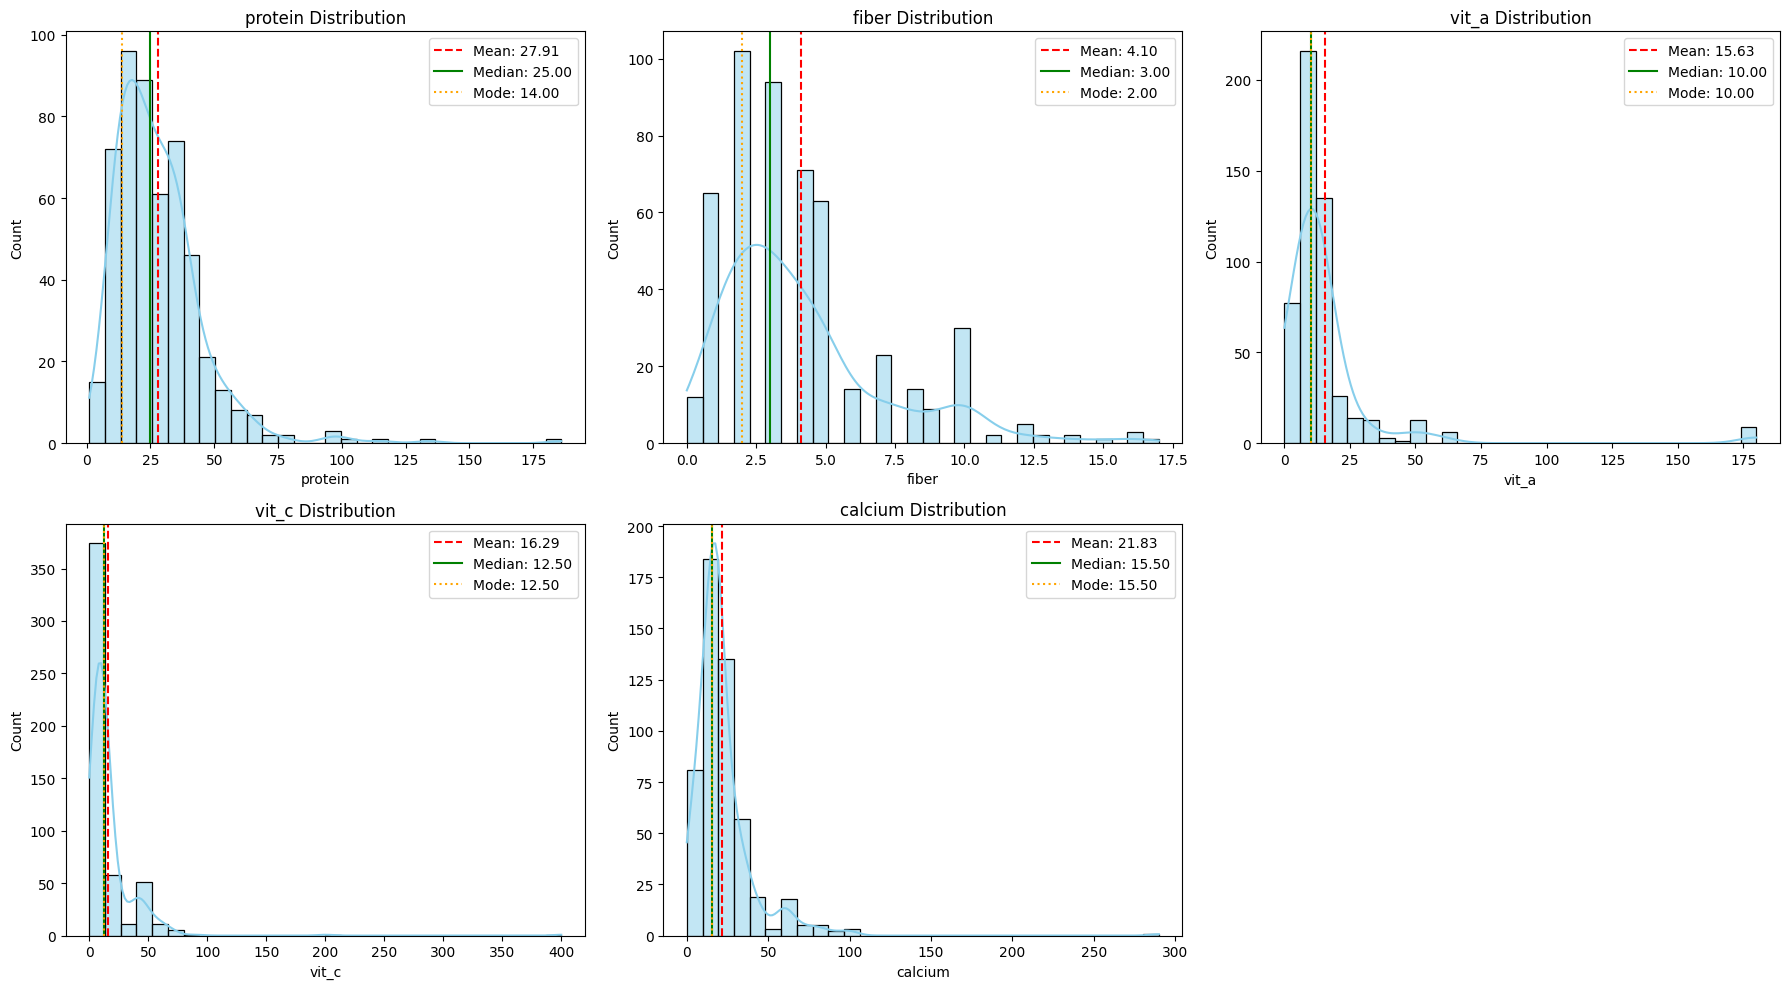

In [ ]:
num_cols = len(micro_nutrient_columns)
num_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(micro_nutrient_columns):
    ax = axes[i]

    micro_mean_val = summary_table.loc[col, 'Mean']
    micro_median_val = summary_table.loc[col, 'Median']
    micro_mode_val = summary_table.loc[col, 'Mode']

    sns.histplot(df[col], kde=True, bins=30, color='skyblue', ax=ax)

    ax.axvline(micro_mean_val, color='red', linestyle='--', label=f'Mean: {micro_mean_val:.2f}')
    ax.axvline(micro_median_val, color='green', linestyle='-', label=f'Median: {micro_median_val:.2f}')
    ax.axvline(micro_mode_val, color='orange', linestyle=':', label=f'Mode: {micro_mode_val:.2f}')

    ax.set_title(f'{col} Distribution')
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation for Micro-Nutrients Distribution with Mean,Median,Mode**

* **Right-Skewed Distributions:** All micro-nutrients show right-skewed distributions, meaning most items have low values, with a few high outliers.

* **Mode < Median < Mean:** This consistent pattern confirms the right-skewness across all micro-nutrients, with the mean being pulled higher by outliers.

* **Fiber, Vit A, Vit C, Calcium:** These are generally low in junk food, with typical items (median/mode) containing minimal amounts.

* **Outlier Influence:** A small number of items with very high values for certain nutrients (e.g., protein, vit_c, calcium) don't represent the overall nutritional profile of junk food.

**Micro-Nutrients:Range**

In [ ]:
micro_nutrient_columns_summary= pd.DataFrame({
    'Min': df[micro_nutrient_columns].min(),
    'Max': df[micro_nutrient_columns].max()
})
print("MEASURE OF DISPERSION: RANGE \n",micro_nutrient_columns_summary)


MEASURE OF DISPERSION: RANGE 
          Min    Max
protein  1.0  186.0
fiber    0.0   17.0
vit_a    0.0  180.0
vit_c    0.0  400.0
calcium  0.0  290.0


**Bar chart for Micro-Nutrients:Range**

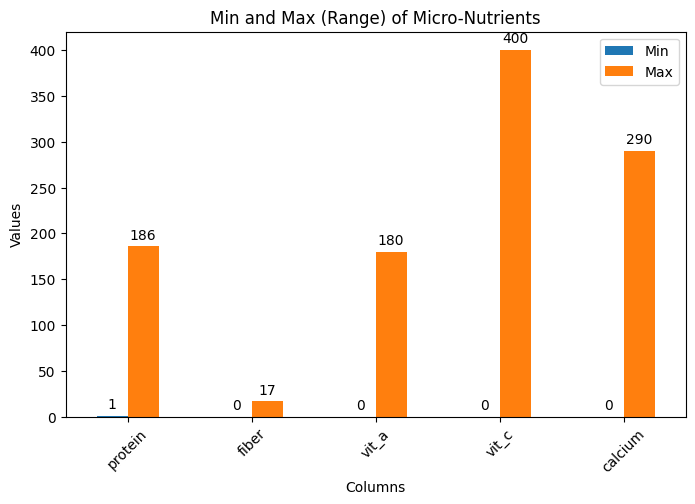

In [ ]:
ax = micro_nutrient_columns_summary.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)


plt.title('Min and Max (Range) of Micro-Nutrients')
plt.ylabel('Values')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.show()


**Interpretation of the Micro-Nutrients Range Bar Chart**

* **Vitamin C** also has a very wide range (0 - 400 units), suggesting some items are fortified or naturally rich, while many have none.

* **Protein, Vitamin A, and Calcium** also have considerable ranges, highlighting diverse presence but often low overall levels.

* **Fiber** has the narrowest and lowest range (0g - 17g), confirming junk food is generally a poor source of this nutrient with little variability.

Overall, the chart reveals significant nutritional variability and extremes, with key health implications for **high sodium and low fiber content** in most junk food items.

**Micro-Nutrients: Measure of Dispersion using Variance and Standard deviation**

In [ ]:
#Variance & Std of Micro-Nutrients
variance_table = df[micro_nutrient_columns].var().to_frame(name='Variance')
std_table =df[micro_nutrient_columns].std().to_frame(name='STD')

# variance and standard deviation in a single table
dispersion_table = pd.concat([variance_table, std_table], axis=1)

print("Measure of Dispersion-- Micro-Nutrients: Variance And Standard Deviation \n")
print(dispersion_table)

Measure of Dispersion-- Micro-Nutrients: Variance And Standard Deviation 

           Variance        STD
protein  313.130262  17.695487
fiber      9.044393   3.007390
vit_a    592.574706  24.342857
vit_c    579.830668  24.079673
calcium  402.163248  20.054008


**Interpretation for Measure of Dispersion-- Micro-Nutrients: Variance And Standard Deviation**

* **Vitamin A**(STD 24.34), **Vitamin C** (STD 24.08), and **Calcium** (STD 20.05) also show significant dispersion, suggesting considerable variability in their levels across different items.

* **Protein** (STD 17.70) has a moderate level of dispersion, implying its content varies noticeably but less dramatically than sodium or vitamins.

* **Fiber** (STD 3.01) has the lowest Variance and STD, confirming that its content is consistently low across most junk food items, with very little deviation.

**Percentile Table:Micro-Nutrients**

In [ ]:
Micro_percentiles = df[micro_nutrient_columns].quantile([0.25, 0.50, 0.75])
Micro_percentiles

,protein,fiber,vit_a,vit_c,calcium
0.25,16.0,2.0,10.0,8.0,15.0
0.50,25.0,3.0,10.0,12.5,15.5
0.75,36.0,5.0,15.0,15.0,25.0


**Interpretation for percentile distribution of Micro-Nutrients**

*  **Protein** 75% of items contain 36g or less, with a median of 25g. This suggests a good range, but also many items with moderate protein.

* **Fiber:** 75% of items have only 5g of fiber or less, and half have 3g or less, highlighting consistently low fiber content in junk food.

* **Vitamin A**75% of items contain 15 units or less, and half have 10 units or less, indicating low to moderate levels for most items.

* **Vitamin C:** 75% of items have 15 units or less, with a median of 12.5 units. Similar to Vitamin A, most items offer limited Vitamin C.

* **Calcium** 75% of items contain 25 units or less, and half have 15.5 units or less, indicating generally low calcium content across products.


**Micro-Nutrients:Box Plot Representing Percentile Distribution and Spread**

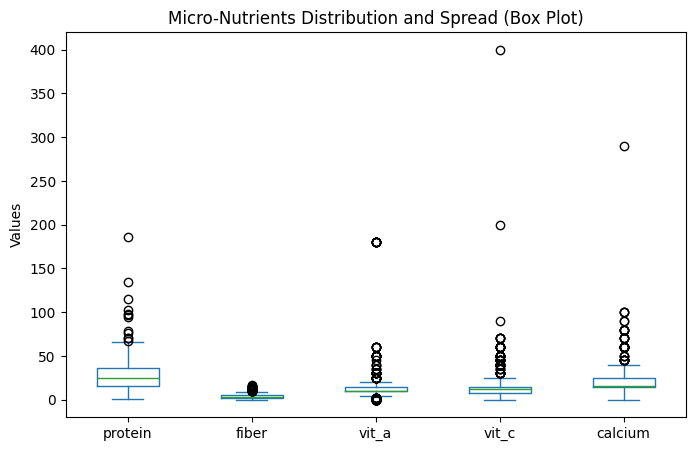

In [ ]:
df[micro_nutrient_columns].plot(kind='box', figsize=(8,5))
plt.title('Micro-Nutrients Distribution and Spread (Box Plot)')
plt.ylabel('Values')
plt.show()


**Interpretation for Micro-Nutrients Box Plot**

* **Protein** Moderate spread, median around 25g, with several upper outliers indicating some very high-protein items.

*  **Fiber** Very compact box (median 3g, IQR 2-5g), confirming consistently low  content across most items.

* **Vitamin A** Box concentrated at lower values (median ~10 units), but many high outliers show some significantly richer items.

* **Vitamin C** Similar low median (~12.5 units) but numerous high outliers, suggesting some items are exceptionally high, possibly fortified.

* **Calcium** Low box (median ~15.5 units), indicating most junk food is poor in calcium, but some upper outliers suggest fortified products.

Overall the Box plots visually confirm right-skewed distributions and numerous high-value outliers for most nutrients, especially sodium, vitamin C, and calcium, impacting their mean values.


**Micro-Nutrients: Deviation from Mean**

In [ ]:
# Calculate mean for each column
micro_mean_val = df[micro_nutrient_columns].mean()
# Deviation from mean
deviation = df[micro_nutrient_columns] - micro_mean_val
deviation

,protein,fiber,vit_a,vit_c,calcium
0,9.091618,-1.101365,-11.630604,3.711501,-1.832359
1,18.091618,-2.101365,-9.630604,3.711501,-1.832359
2,42.091618,-1.101365,-5.630604,3.711501,28.167641
3,27.091618,-2.101365,-9.630604,8.711501,-1.832359
4,18.091618,-0.101365,-9.630604,3.711501,-1.832359
...,...,...,...,...,...
509,-4.908382,4.898635,-0.630604,-10.288499,3.167641
510,-4.908382,4.898635,4.369396,-6.288499,3.167641
512,-1.908382,6.898635,-5.630604,-3.788499,-6.332359
513,4.091618,3.898635,-5.630604,-3.788499,-6.332359


**Bar Chart of Deviation of Micro-Nutrients from the Mean**

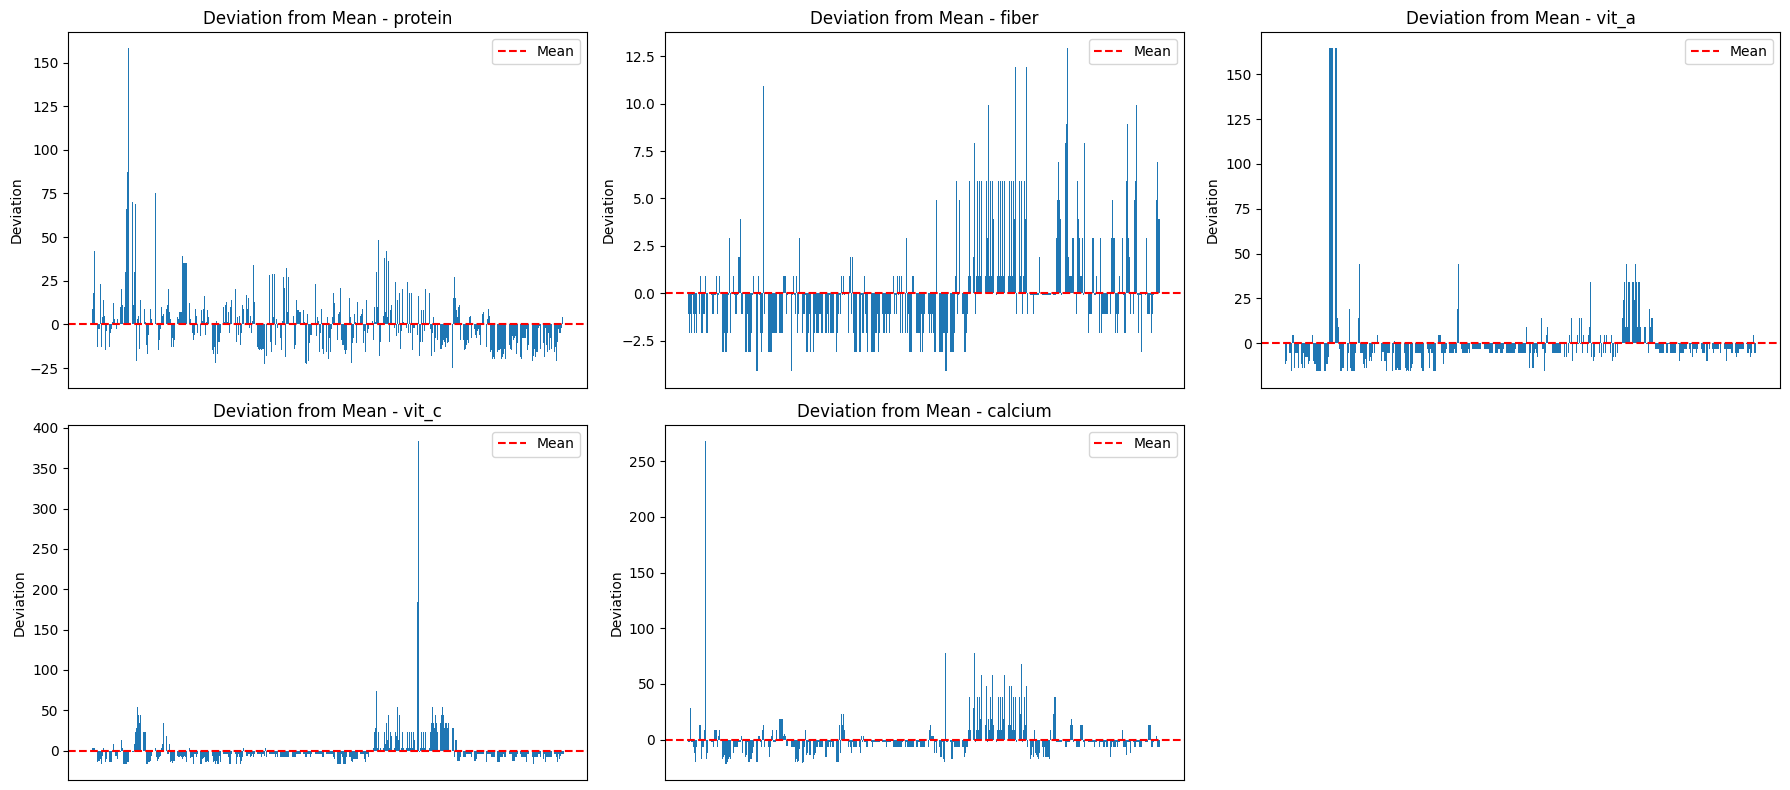

In [ ]:
num_cols = len(micro_nutrient_columns)
num_rows = (num_cols + 2) // 3 # Roughly 3 columns per row

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(micro_nutrient_columns):
    ax = axes[i]
    ax.bar(range(len(deviation)), deviation[col])
    ax.axhline(0, color='red', linestyle='--', label='Mean')
    ax.set_title(f'Deviation from Mean - {col}')
    ax.set_ylabel('Deviation')
    ax.set_xticks([])  # remove x-axis labels
    ax.legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation for Bar Chart of Deviation of Micro-Nutrients from the Mean**

* **Protein:** Shows mixed deviations; many items are near or below the mean, but significant positive spikes indicate a few very high-protein items.

* **Fiber:** Deviations are mostly negative or near zero, confirming consistently low fiber content across nearly all items.

* **Vitamin A:** Many items are below average, but notable positive deviations show a subset with considerably higher Vitamin A content.

* **Vitamin C:** Similar to Vitamin A, a majority are below average, but distinct large positive deviations suggest some items are particularly rich.

* **Vitamin C:** Similar to Vitamin A, a majority are below average, but distinct large positive deviations suggest some items are particularly rich.

* **Calcium:** Most items are at or below the mean, but a few very tall positive bars highlight a small number of exceptionally high-calcium items.

Overall The charts visually confirm high variability and the presence of significant positive outliers for most nutrients, driving up their average values.

**Micro-Nutrients: Measure of Distribution using Skewness & Krutosis**

In [ ]:
#Skewness & Krutosis of Micro-Nutrients
Skewness_table = df[micro_nutrient_columns].skew().to_frame(name='Skewness')
Krutosis_table =df[micro_nutrient_columns].kurtosis().to_frame(name='Krutosis')

# Skewness & Krutosis in a single table
distribution_table = pd.concat([Skewness_table, Krutosis_table], axis=1)

print("Measure of Distribution-- Micro-Nutrients: Skewness & Krutosis \n")
print(distribution_table)

Measure of Distribution-- Micro-Nutrients: Skewness & Krutosis 

         Skewness    Krutosis
protein  2.809693   16.461222
fiber    1.432463    2.194993
vit_a    5.554115   34.223162
vit_c    9.208741  131.979377
calcium  5.750752   63.745299


**Histplot of Micro-Nutrients: Measure of Distribution using Skewness**

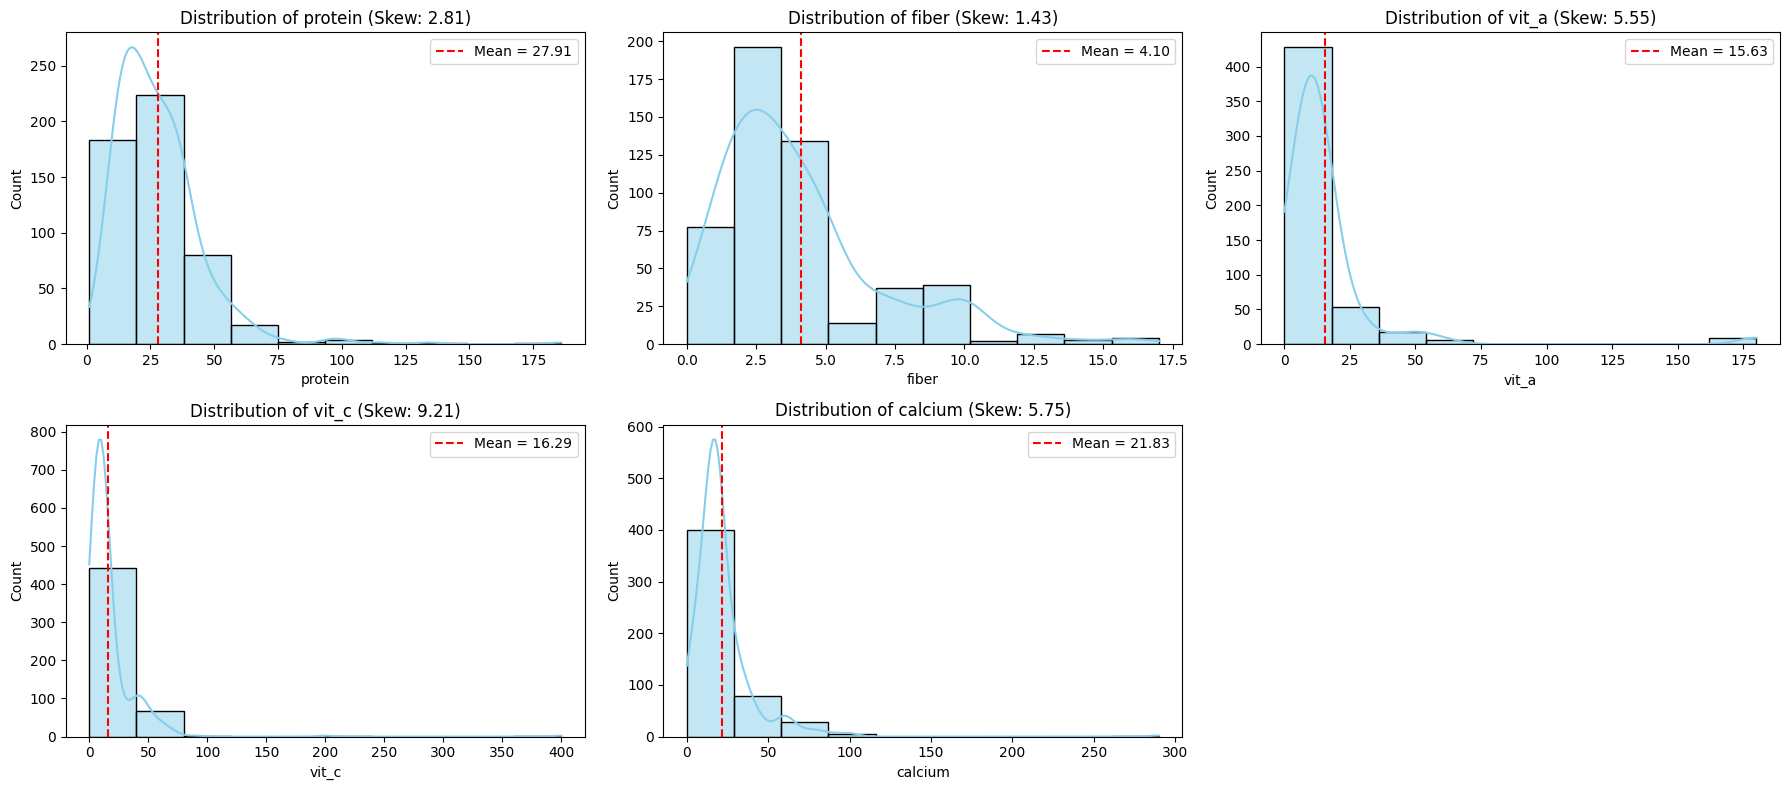

In [ ]:
num_cols = len(micro_nutrient_columns)
num_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(micro_nutrient_columns):
    ax = axes[i]
    sns.histplot(df[col], kde=True, bins=10, color='skyblue', ax=ax)

    # Mean line
    micro_mean_val = df[col].mean()
    ax.axvline(micro_mean_val, color='red', linestyle='--', label=f'Mean = {micro_mean_val:.2f}')

    # Title with Skewness
    skew_val = df[col].skew()
    ax.set_title(f'Distribution of {col} (Skew: {skew_val:.2f})')

    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(loc='upper right')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation for Histplot of Micro-Nutrients (Skewness)**

* **Protein** (Skewness: 2.81): Highly right-skewed, meaning most items have low protein content, with a few items having very high amounts.

* **Fiber** (Skewness: 1.43): Moderately right-skewed, indicating a greater number of items with lower fiber values.

* **Vitamin A** (Skewness: 5.55): Very highly right-skewed, showing that most items contain minimal Vitamin A, with rare exceptions of higher values.

* **Vitamin C** (Skewness: 9.21): Extremely right-skewed, signifying an overwhelming concentration of items with very little Vitamin C, but a few items having exceptionally high levels.

* **Calcium** (Skewness: 5.75): Very highly right-skewed, indicating that the majority of items are low in calcium, with a long tail towards higher values

**KDE/Density chart of Micro-Nutrients: Measure of Distribution using Krutosis**

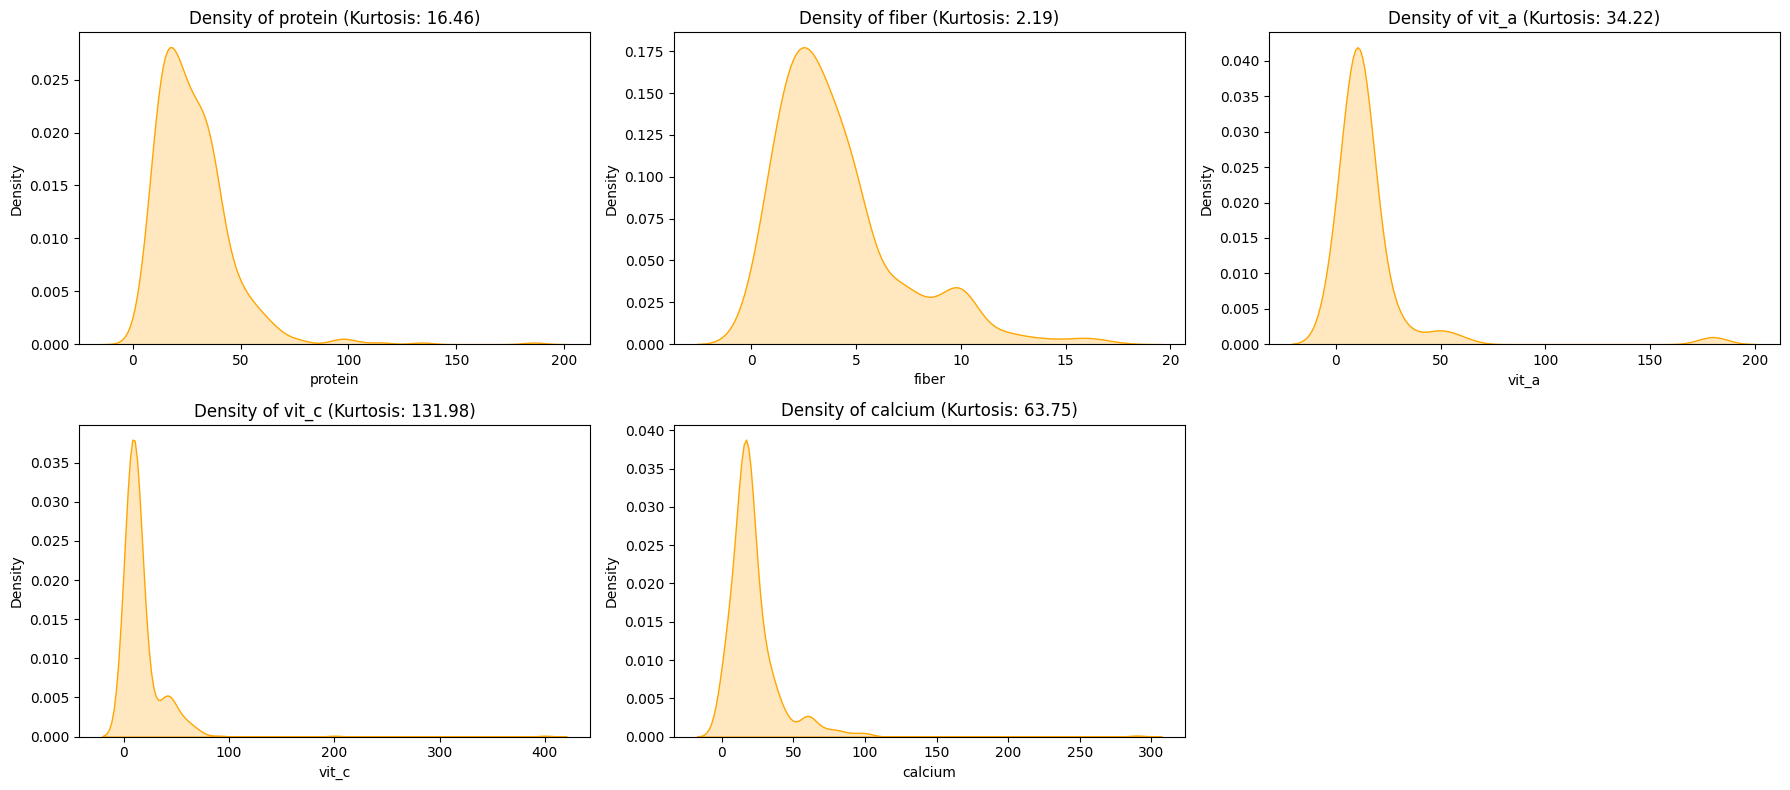

In [ ]:
num_cols = len(micro_nutrient_columns)
num_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(micro_nutrient_columns):
    ax = axes[i]
    sns.kdeplot(df[col], fill=True, color='orange', ax=ax)  # density plot only
    kurt_val = df[col].kurt()

    ax.set_title(f'Density of {col} (Kurtosis: {kurt_val:.2f})')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation for KDE/Density Chart of Micro-Nutrients (Kurtosis)**

* **Protein** (Kurtosis: 16.46): Highly leptokurtic, indicating a very sharp peak around the mode and heavy tails, implying many values cluster closely, but there are significant outliers.

* **Fiber** (Kurtosis: 2.19): Slightly platykurtic (flatter than a normal distribution), suggesting a broader spread of values around the mean, but still concentrated at the low end due to skewness.

* **Vitamin A** (Kurtosis: 34.22): Very highly leptokurtic, showing an extremely sharp peak at low values and very heavy tails due to significant outliers.

* **Vitamin C **(Kurtosis: 131.98): Extremely leptokurtic, signifying a very pronounced peak and extremely heavy tails, indicating that most values are concentrated at the very low end, with extreme outliers.

* **Calcium** (Kurtosis: 63.75): Highly leptokurtic, indicating a very sharp peak at low values and very heavy tails from significant outliers.

**Central Tendancy for Macro columns**

In [ ]:
macro_nutrient_cols = ['cal_fat', 'total_fat', 'sat_fat', 'trans_fat','cholesterol', 'sodium','total_carb', 'sugar']

**Summary Statistics table for Macro-Nutirentients**

In [ ]:
#summary table for macro_nutrient_cols
summary_table = pd.DataFrame({
    'Mean': df[macro_nutrient_cols].mean(),
    'Median': df[macro_nutrient_cols].median(),
    'Mode': df[macro_nutrient_cols].mode().iloc[0]
})
# Display the table
print("MEASURE OF CENTRAL TENDENCY\n", summary_table)


MEASURE OF CENTRAL TENDENCY
                     Mean  Median    Mode
cal_fat       238.945419   210.0   160.0
total_fat      26.604288    23.0    18.0
sat_fat         8.152047     7.0     4.0
trans_fat       0.462963     0.0     0.0
cholesterol    72.553606    60.0    40.0
sodium       1247.309942  1110.0  1120.0
total_carb     45.647173    44.0    44.0
sugar           7.272904     6.0     7.0


**Interpretation for Centrsl Teneny for Macro-Nutrients**

* **Fat-related (cal_fat, total_fat, sat_fat, cholesterol)** Generally right-skewed (Mean > Median > Mode), indicating many items have lower values but outliers drive up the average, especially for cholesterol.

* **Trans Fat** Predominantly zero (Mode = 0), with a slight right-skew (Mean > Median = Mode), meaning most items have no trans fat but some contain it.

* **Total Carbohydrates** Mean, median, and mode are very close(all around
44g),suggesting a more balanced distribution

* **Sugar** lightly right-skewed (Mean > Median), indicating many items have low sugar but some contribute more.

**Macro-Nutrients Distribution with Mean,Median,Mode using subplots**

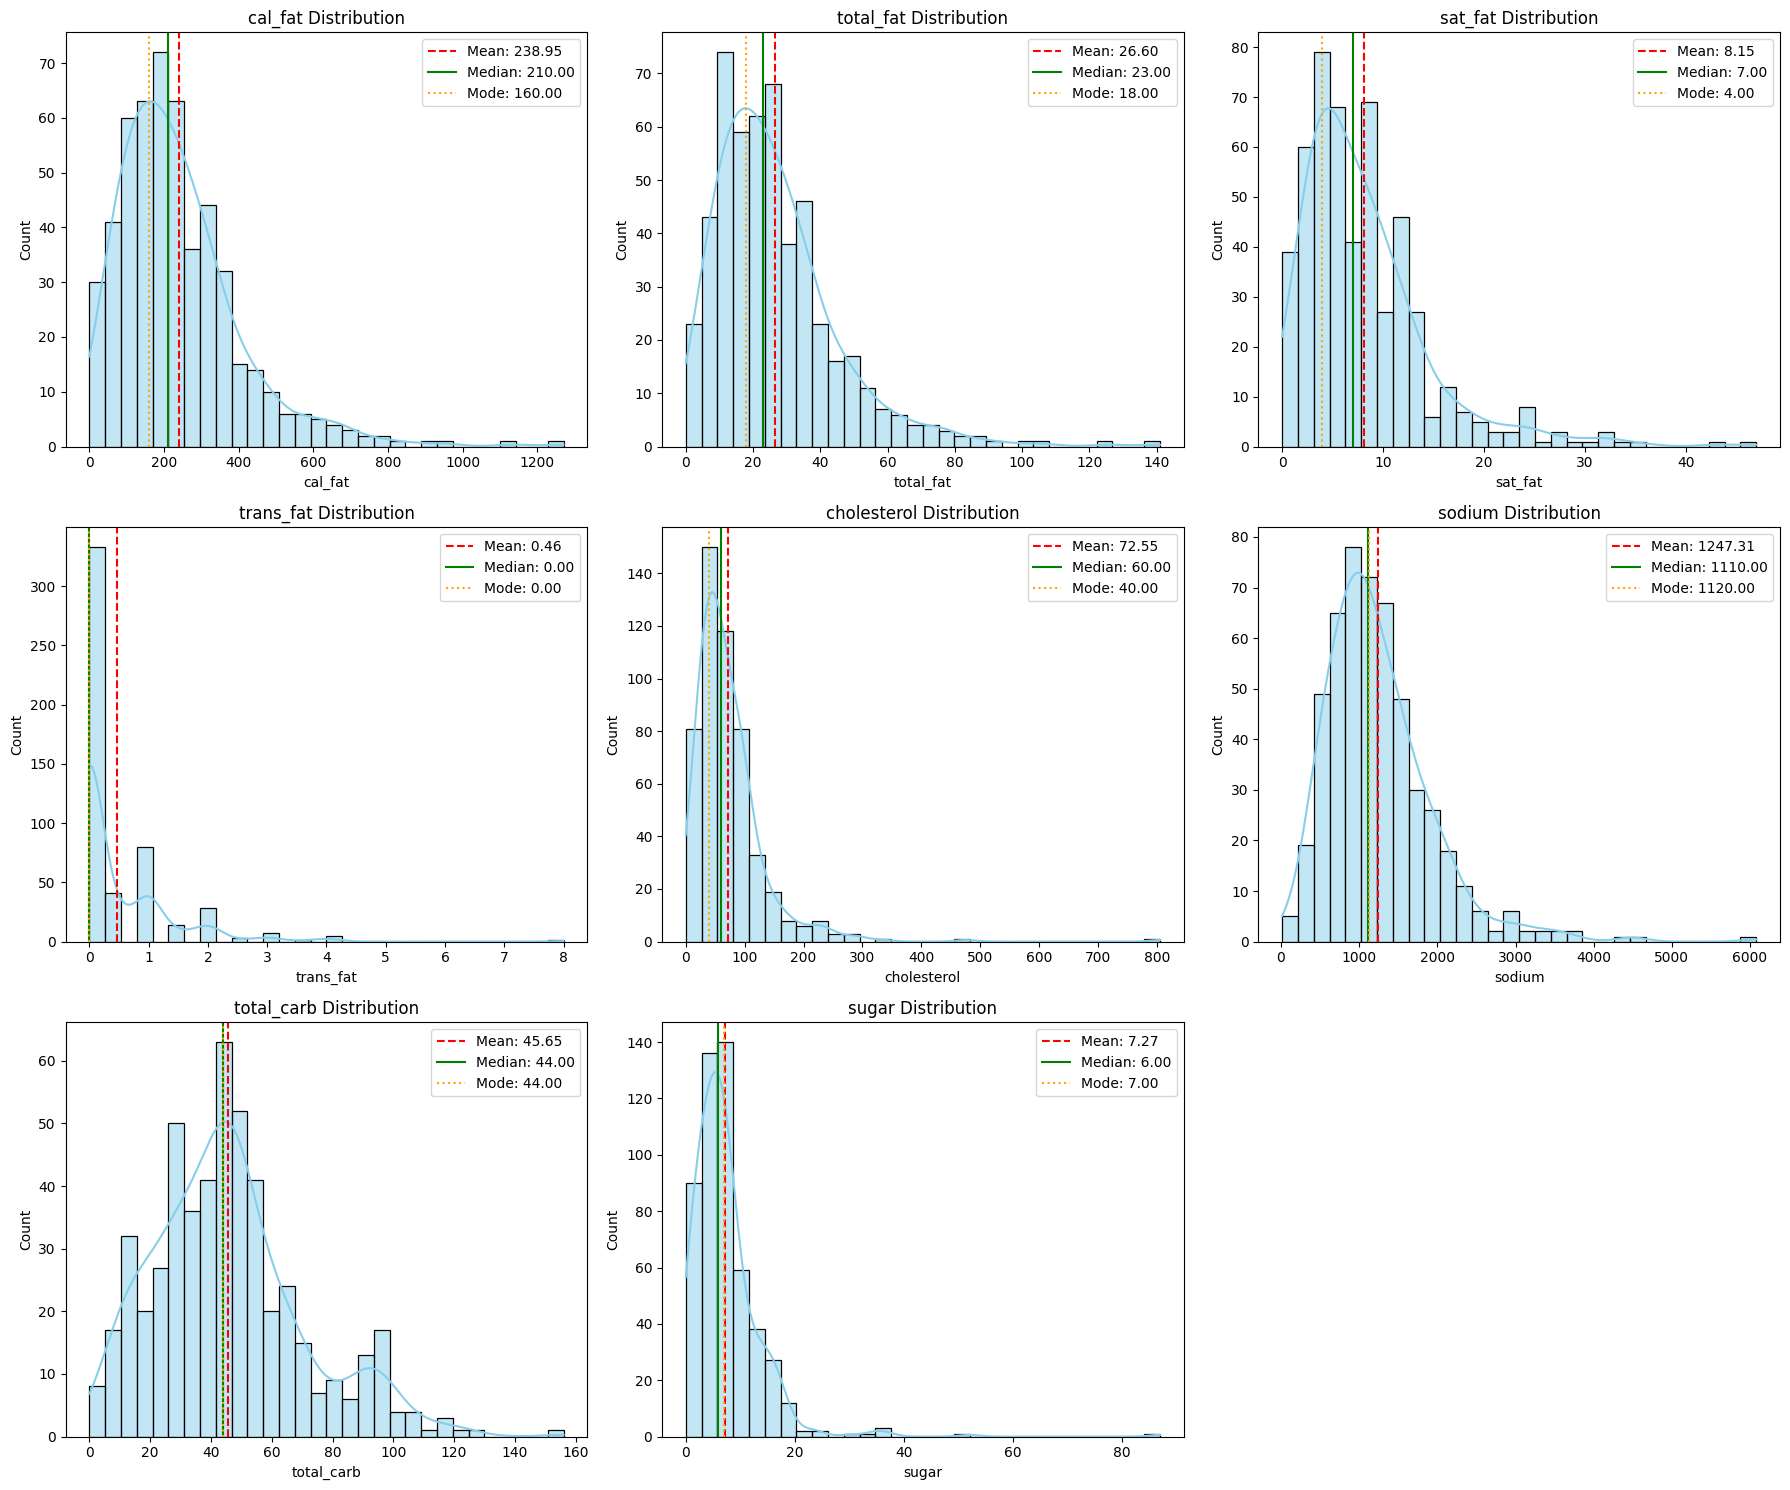

In [ ]:
num_cols = len(macro_nutrient_cols)
num_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(macro_nutrient_cols):
    ax = axes[i]

    macro_mean_val = summary_table.loc[col, 'Mean']
    macro_median_val = summary_table.loc[col, 'Median']
    macro_mode_val = summary_table.loc[col, 'Mode']

    sns.histplot(df[col], kde=True, bins=30, color='skyblue', ax=ax)

    ax.axvline(macro_mean_val, color='red', linestyle='--', label=f'Mean: {macro_mean_val:.2f}')
    ax.axvline(macro_median_val, color='green', linestyle='-', label=f'Median: {macro_median_val:.2f}')
    ax.axvline(macro_mode_val, color='orange', linestyle=':', label=f'Mode: {macro_mode_val:.2f}')

    ax.set_title(f'{col} Distribution')
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation points for the Macro-Nutrients Distribution with Mean, Median, Mode:**

* **Fats, Cholesterol, Sugar** Show right-skewed distributions (Mean > Median > Mode), indicating many items have lower values but outliers pull up the average.

* **Trans Fat** Mode often at zero, signifying many items have no trans fat, but some outliers exist.

* **Total Carbohydrates** More balanced distribution (Mean ≈ Median ≈ Mode) around 44g.

* **Outlier Effect** High values for some items (especially fats/sugar) significantly influence the mean, distorting the 'average' typical content.


**Macro-Nutrientients:Range**

In [ ]:
macro_nutrient_columns_summary= pd.DataFrame({
    'Min': df[macro_nutrient_cols].min(),
    'Max': df[macro_nutrient_cols].max()
})
print("MEASURE OF DISPERSION: RANGE \n",macro_nutrient_columns_summary)

MEASURE OF DISPERSION: RANGE 
               Min     Max
cal_fat       0.0  1270.0
total_fat     0.0   141.0
sat_fat       0.0    47.0
trans_fat     0.0     8.0
cholesterol   0.0   805.0
sodium       15.0  6080.0
total_carb    0.0   156.0
sugar         0.0    87.0


**Interpretation for Macro-Nutrientients : Range**

* **Calories from Fat (cal_fat)** Ranges from 0 to 1270, indicating a very wide spread from no fat calories to extremely high.

* **Total Fat** Shows a range from 0 to 141 grams, implying significant variability in fat content across items.

*  **Saturated Fat** Ranges from 0 to 47 grams, highlighting a broad spectrum from fat-free to very high in saturated fat.

* **Trans Fat** Has a narrow range of 0 to 8 grams, with many items likely containing very little to no trans fat, but some having a notable amount.

* **Cholesterol** Ranges from 0 to 805, demonstrating extreme variability from items with no cholesterol to those with very high levels.

* **Total Carbohydrates** Varies from 0 to 156 grams, showing a wide distribution of carb content.

Mean (1247mg) > Median (1110mg) > Mode (1120mg), indicating a right-skewed distribution with high outliers.


* **Sugar** Ranges from 0 to 87 grams, indicating that some junk food has no added sugar, while others contain exceptionally high amounts.

**Bar chart for Macro-Nutrients:Range**

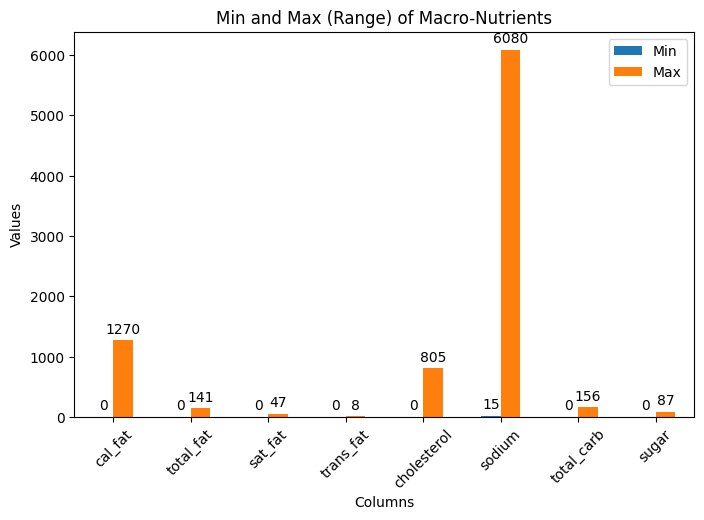

In [ ]:
ax = macro_nutrient_columns_summary.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)


plt.title('Min and Max (Range) of Macro-Nutrients')
plt.ylabel('Values')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.show()

**Interpretation points for the Bar chart of Macro-Nutrients:Range**

* **Calories from Fat (cal_fat)** Shows a very wide range (0 to 1270), indicating extreme variability from fat-free to very high-calorie options.

* **Total Fat**  Has a broad range (0 to 141g), highlighting significant diversity in overall fat content.

* **Saturated Fat**Ranges from 0 to 47g, confirming a wide spectrum from negligible to very high saturated fat levels.

* **Trans Fat** Features a narrower range (0 to 8g), suggesting many items have little to no trans fat, but some contain notable amounts.

* **Cholesterol** Displays an extensive range (0 to 805 units), from cholesterol-free items to those with exceptionally high levels.

* **Total Carbohydrates** Varies considerably (0 to 156g), indicating a broad distribution of carbohydrate content.

Sodium Ranges from 15mg to 6080mg, showing vast variability from low to extremely high.


*  **Sugar** Ranges from 0 to 87g, revealing that some junk foods are sugar-free while others are exceptionally high in sugar

**Macro-Nutrients: Measure of Dispersion using Variance and Standard deviation**

In [ ]:
#Variance & Std of Macro-Nutrients
variance_table = df[macro_nutrient_cols].var().to_frame(name='Variance')
std_table =df[macro_nutrient_cols].std().to_frame(name='STD')

# variance and standard deviation in a single table
dispersion_table = pd.concat([variance_table, std_table], axis=1)

print("Measure of Dispersion-- Macro-Nutrients: Variance And Standard Deviation \n")
print(dispersion_table)

Measure of Dispersion-- Macro-Nutrients: Variance And Standard Deviation 

                  Variance         STD
cal_fat       27783.329046  166.683320
total_fat       340.130216   18.442620
sat_fat          41.360626    6.431223
trans_fat         0.706633    0.840615
cholesterol    4001.767140   63.259522
sodium       477699.097108  691.157795
total_carb      621.209255   24.924070
sugar            45.839440    6.770483


**Interpretation points for Variance and Standard Deviation of Macro-Nutrients**

* **Calories from Fat (cal_fat)** Has the highest variance (27783) and STD (166.68), indicating extreme variability in fat calorie content across items.

* **Total Fat** Shows high dispersion (STD 18.44), meaning its content varies significantly across junk food.

* **Saturated Fat** Displays moderate dispersion (STD 6.43), suggesting noticeable variability but less than total fat.

* **Trans Fat** Has the lowest STD (0.84), implying very consistent and generally low levels of trans fat across most items.

* **Cholesterol** Exhibits high dispersion (STD 63.26), indicating wide variability from very low to very high cholesterol content.

* **Total Carbohydrates** Shows significant dispersion (STD 24.92), meaning carb content varies considerably among items.


High Variance (477699) and STD (691) confirm highly inconsistent sodium levels.

* **Sugar** Has moderate dispersion (STD 6.77), indicating varied sugar levels, but less extreme variability than fat or cholesterol


**Percentile Table:Macro-Nutrients**

In [ ]:
Macro_percentiles = df[macro_nutrient_cols].quantile([0.25, 0.50, 0.75])
Macro_percentiles

,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,sugar
0.25,120.0,14.0,4.0,0.0,35.0,800.0,28.0,3.0
0.50,210.0,23.0,7.0,0.0,60.0,1110.0,44.0,6.0
0.75,310.0,35.0,11.0,1.0,95.0,1550.0,57.0,9.0


**Macro-Nutrients:Box Plot Representing Percentile Distribution and Spread**

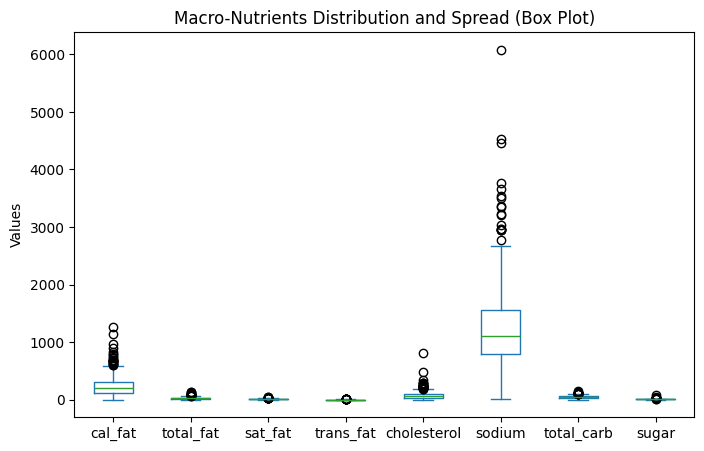

In [ ]:
df[macro_nutrient_cols].plot(kind='box', figsize=(8,5))
plt.title('Macro-Nutrients Distribution and Spread (Box Plot)')
plt.ylabel('Values')
plt.show()

**Interpretation for Macro-Nutrients:Box Plot**

* **Calories from Fat** Very wide spread (median high), many extreme upper outliers.

* **Total Fat** Broad distribution (median ~23g), numerous high outliers.

* **Saturated Fat** Box lower, but many upper outliers for some items.

* **Trans Fat** concentrated (median ~0g),few outliers.

* **Cholesterol** Very low median (~60 units), but significant extreme upper outliers.

* **Total Carbohydrates** Wide spread (median ~44g), several upper outliers.
  x Plot (Cell hWWJ-NLtpO7s):

High median, wide interquartile range, and numerous upper outliers indicate many items are high or extremely high in sodium.


* **Sugar** Box concentrated low (median ~6g), but many extreme upper outliers.

Overall the box plot shows  most show rigt-skewed distributions with high variability and numerous upper outliers.

**Macro-Nutrients:Deviation from Mean**

In [ ]:
# Calculate mean for each macro-nutrient column
macro_mean_val = df[macro_nutrient_cols].mean()
# Deviation from mean for macro-nutrients
macro_deviation = df[macro_nutrient_cols] - macro_mean_val

**Bar Chart of Deviation of Macro-Nutrients from the Mean**

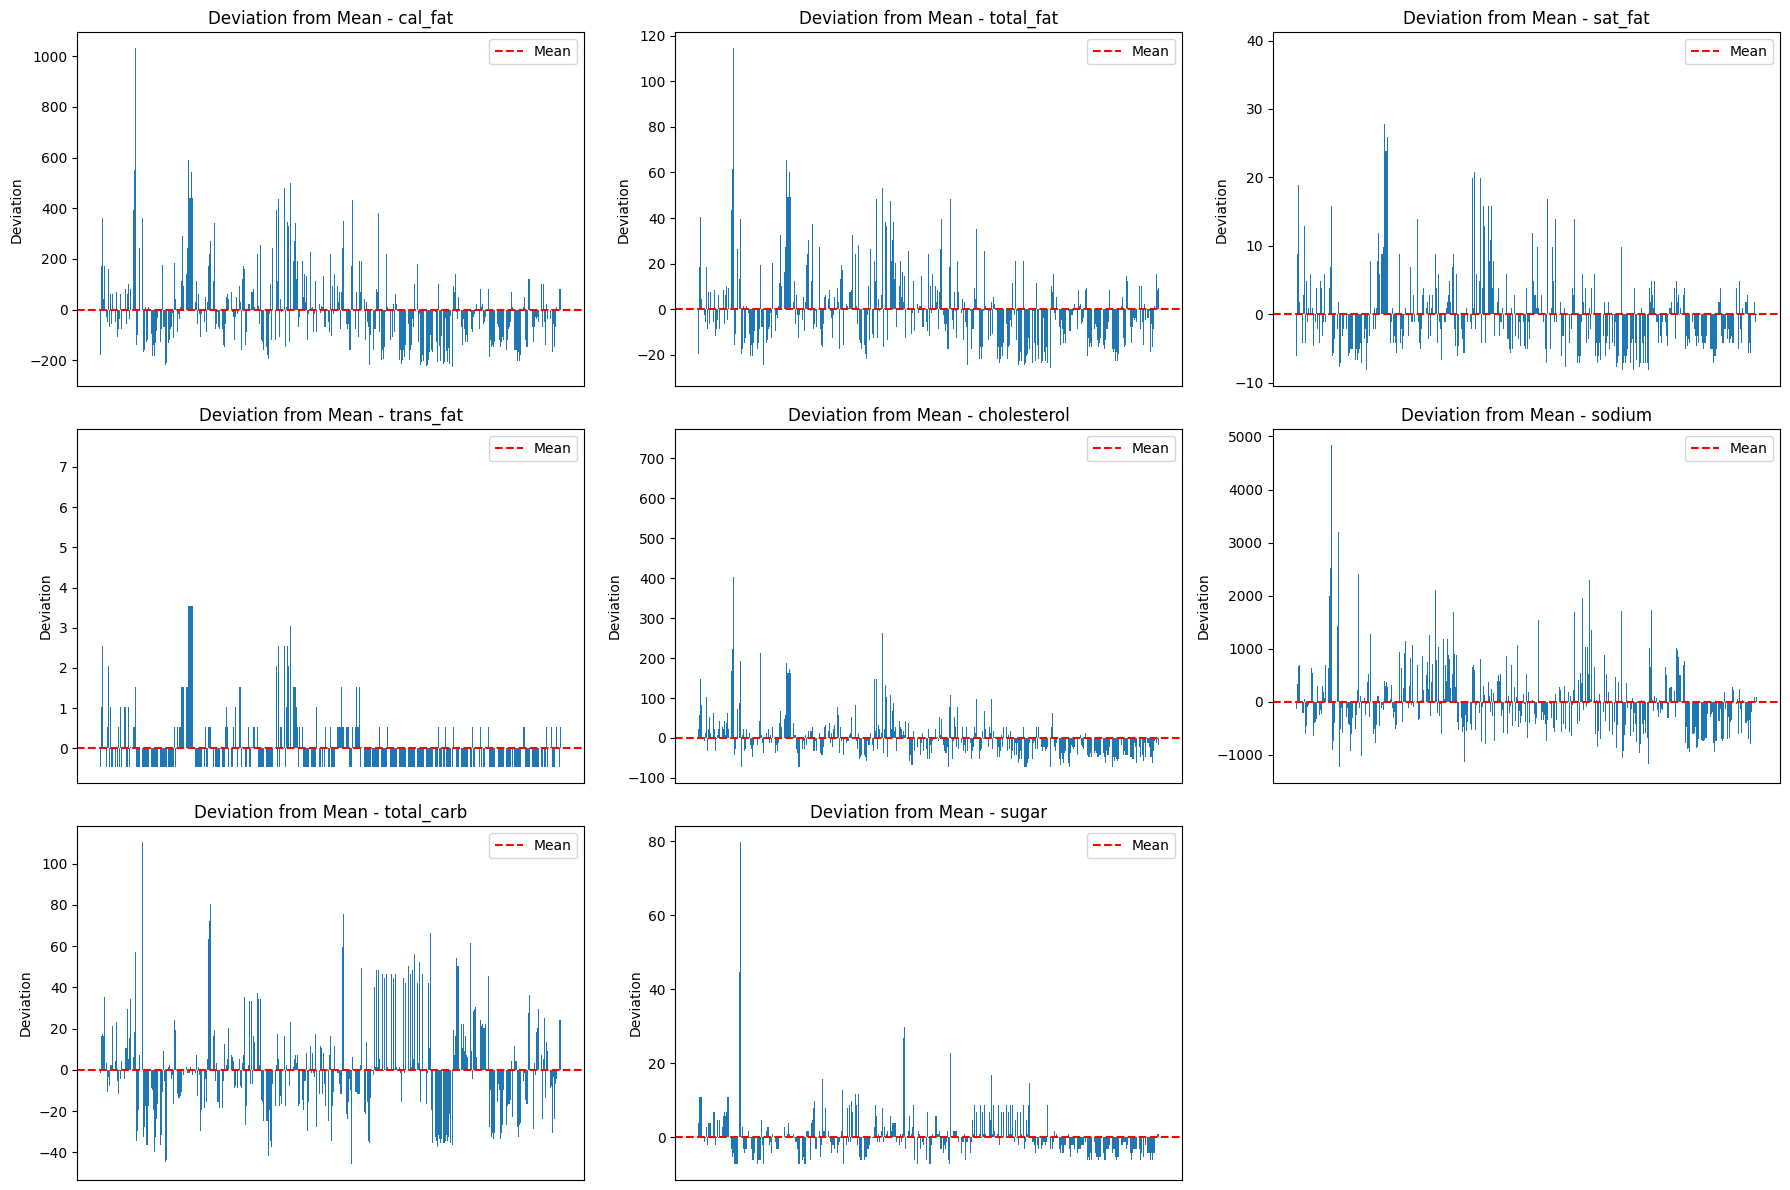

In [ ]:
num_cols = len(macro_nutrient_cols)
num_rows = (num_cols + 2) // 3 # Roughly 3 columns per row

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(macro_nutrient_cols):
    ax = axes[i]
    ax.bar(range(len(macro_deviation)), macro_deviation[col])
    ax.axhline(0, color='red', linestyle='--', label='Mean')
    ax.set_title(f'Deviation from Mean - {col}')
    ax.set_ylabel('Deviation')
    ax.set_xticks([])  # remove x-axis labels
    ax.legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation points for Deviation of Macro-Nutrients from the Mean:**

* **Calories from Fat** Many items show large positive deviations, indicating many calorie-dense items.

* **Total Fat** Wide positive and negative deviations, showing high variability and some very high-fat items.

* **Saturated Fat** Most items at or below mean, but significant positive spikes for a few.

* **Trans Fat** Largely near zero or negative, confirming very low content in most.

* **Cholesterol** Mostly below mean, but a few extreme positive bars indicate very high levels in some.

* **Total Carbohydrates** Balanced mix of positive and negative deviations, suggesting a broad distribution.

Many large positive bars confirm numerous items significantly exceed the average sodium content.


* **Sugar** Many below mean, but frequent large positive bars show numerous high-sugar items.

Overall the deviation bar chart confirms the  high variability and significant positive outliers for fat-related metrics and sugar.

**Macro-Nutrients: Measure of Distribution using Skewness & Krutosis**

In [ ]:
#Skewness & Krutosis of Macro-Nutrients
Skewness_table = df[macro_nutrient_cols].skew().to_frame(name='Skewness')
Krutosis_table =df[macro_nutrient_cols].kurtosis().to_frame(name='Krutosis')

# Skewness & Krutosis in a single table
distribution_table = pd.concat([Skewness_table, Krutosis_table], axis=1)

print("Measure of Distribution-- Macro-Nutrients: Skewness & Krutosis \n")
print(distribution_table)

Measure of Distribution-- Macro-Nutrients: Skewness & Krutosis 

             Skewness   Krutosis
cal_fat      1.777790   5.506677
total_fat    1.788111   5.578628
sat_fat      2.026964   6.179548
trans_fat    3.016137  15.309017
cholesterol  4.412191  38.761318
sodium       1.801018   6.687543
total_carb   0.805618   0.815546
sugar        4.606380  42.181716


**Histplot of Macro-Nutrients: Measure of Distribution using Skewness**

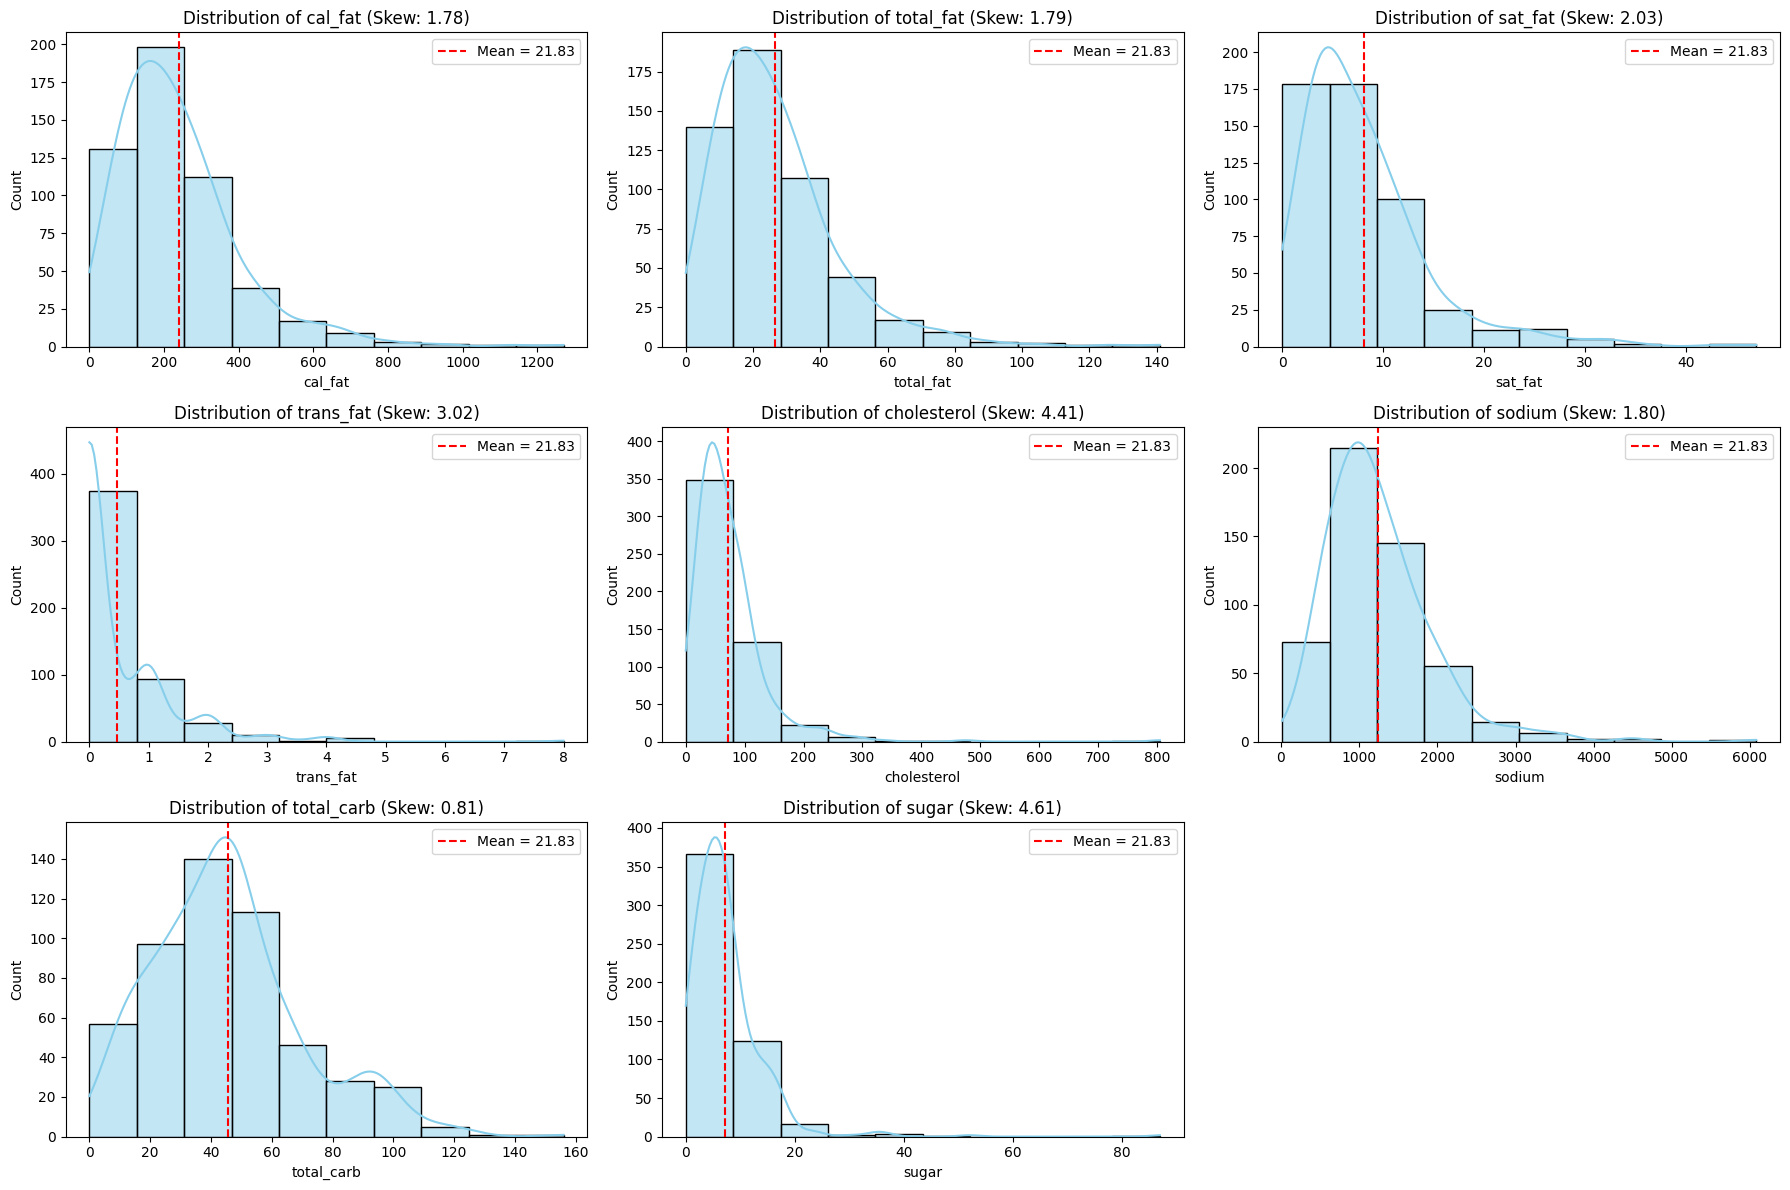

In [ ]:
num_cols = len(macro_nutrient_cols)
num_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(macro_nutrient_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, bins=10, color='skyblue', ax=ax)

    # Mean line
    macro_mean_val = df[col].mean()
    ax.axvline(macro_mean_val, color='red', linestyle='--', label=f'Mean = {micro_mean_val:.2f}')

    # Title with Skewness
    skew_val = df[col].skew()
    ax.set_title(f'Distribution of {col} (Skew: {skew_val:.2f})')

    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(loc='upper right')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretaion for Macro-Nutrients: Measure of Distribution using Skewness**


*  **Calories from Fat** (Skew: 1.78) Moderately right-skewed; many items have lower fat calories.

* **Total Fat**  (Skew: 1.79) Moderately right-skewed; concentration of items with lower total fat.

* **Total Fat**  (Skew: 1.79) Moderately right-skewed; concentration of items with lower total fat.

* **Saturated Fat** (Skew: 2.03) Highly right-skewed; most items have low saturated fat

* **Trans Fat**  (Skew: 3.02) Very highly right-skewed; largely concentrated at zero.

* **Cholesterol**(Skew: 4.41) Extremely right-skewed; most items have low cholesterol, but extreme outliers exist.

* **Total Carbohydrates** (Skew: 0.81) Slightly right-skewed; more balanced distribution with a slight tail.

Highly right-skewed (1.80), indicating a concentration of moderate-to-high sodium items, with a long tail of extreme values

* **Sugar** (Skew: 4.61) Extremely right-skewed; many items have low sugar, but many have very high content.

**KDE/Density chart of Macro-Nutrients: Measure of Distribution using Krutosis**

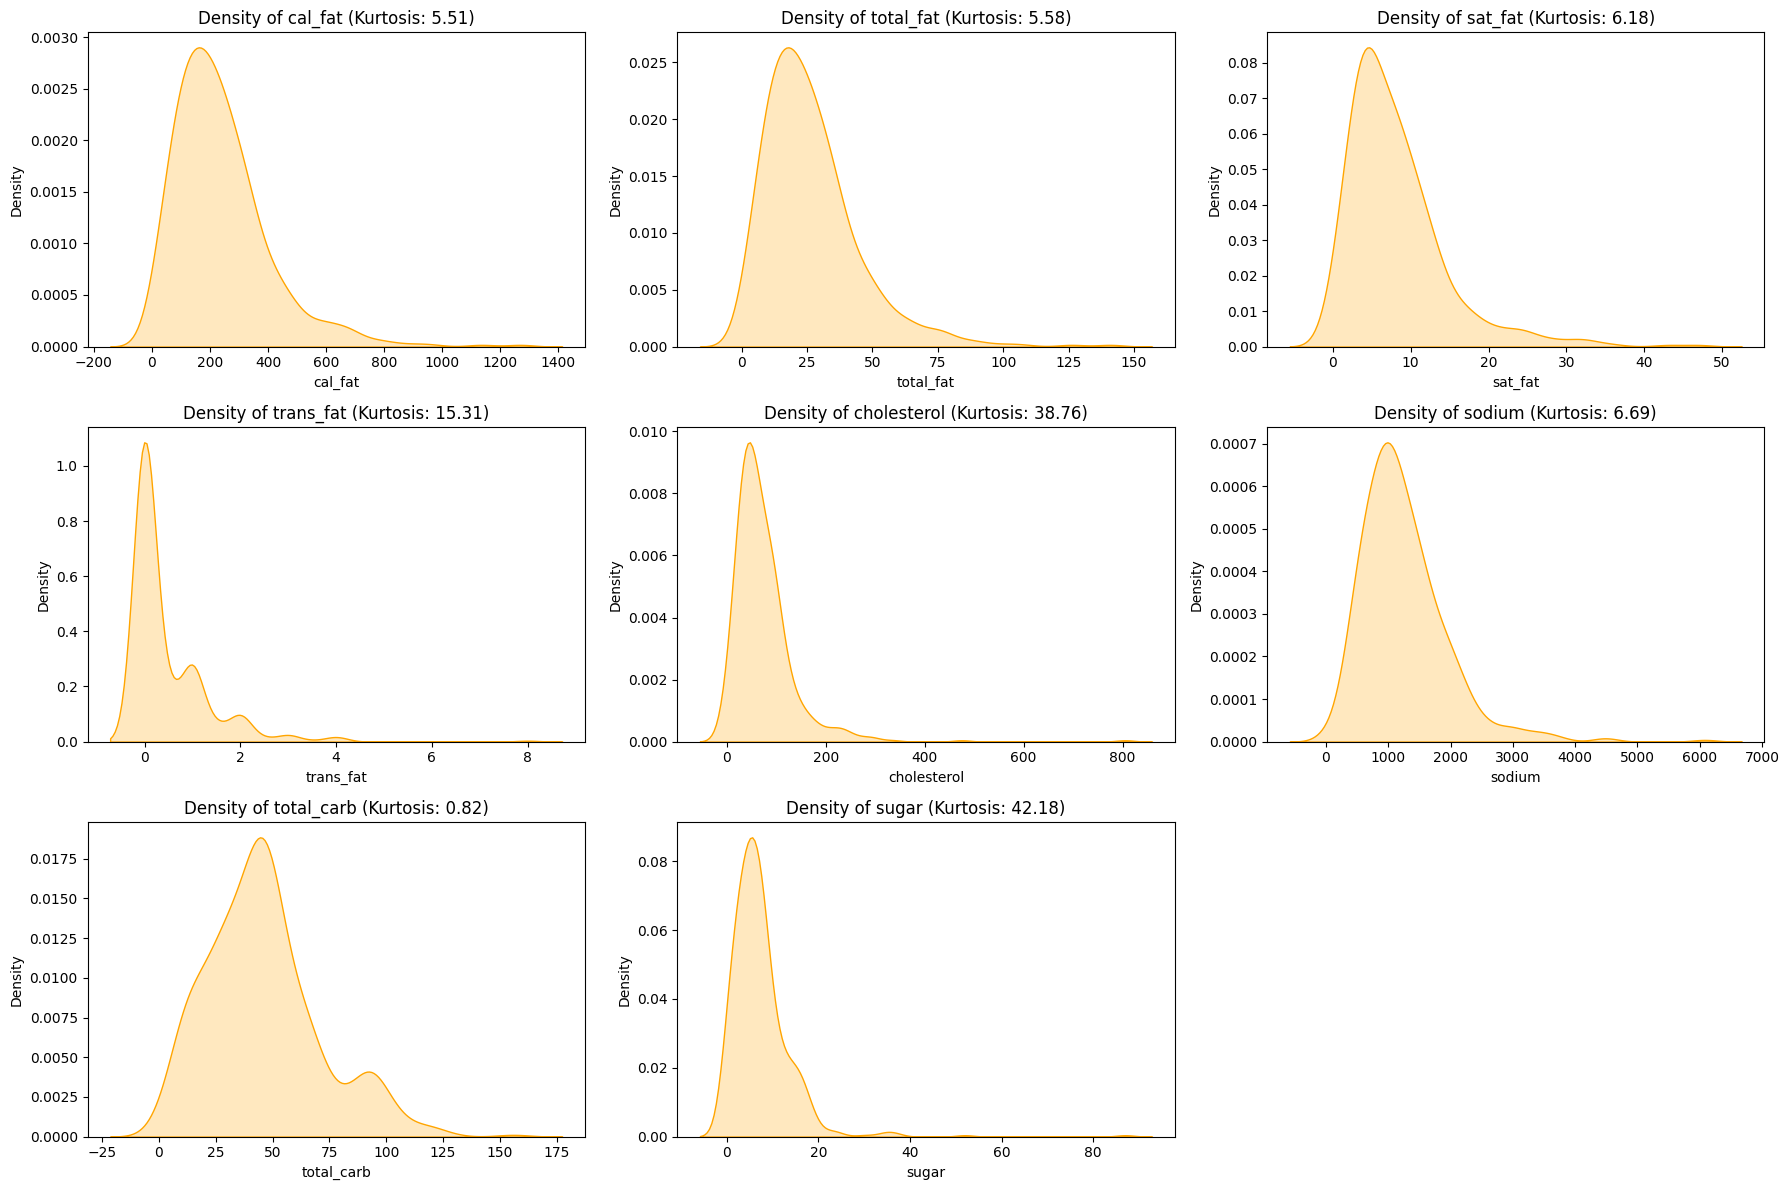

In [ ]:
num_cols = len(macro_nutrient_cols)
num_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(macro_nutrient_cols):
    ax = axes[i]
    sns.kdeplot(df[col], fill=True, color='orange', ax=ax)  # density plot only
    kurt_val = df[col].kurt()

    ax.set_title(f'Density of {col} (Kurtosis: {kurt_val:.2f})')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretaion for Macro-Nutrients:Measure of Distribution using Krutosis**

* **Calories from Fat** (Kurtosis: 5.51) Moderately leptokurtic; sharper peak and heavier tails.

*  **Total Fat** (Kurtosis: 5.58) Moderately leptokurtic; pronounced peak and heavier tails.

* **Saturated Fat** (Kurtosis: 6.18) Moderately leptokurtic; sharp peak at lower values, heavy tails.

*  **Trans Fat** (Kurtosis: 15.31) Highly leptokurtic; very sharp peak near zero, heavy tails from outliers.

* **Cholesterol** (Kurtosis: 38.76) Very highly leptokurtic; extremely sharp peak at low values, very heavy tails.

* **Total Carbohydrates** (Kurtosis: 0.82) Slightly platykurtic; flatter, more uniform spread.

Moderately leptokurtic (6.69), suggesting a sharper peak around typical levels but also significant high outliers.

* **Sugar** (Kurtosis: 42.18) Extremely leptokurtic; very pronounced peak at low values, extremely heavy tails

**Central Tendancy for Calories**

In [ ]:
mean_calories = df['calories'].mean()

median_calories = df['calories'].median()

mode_calories= df['calories'].mode()[0]

print(f"Mean: {mean_calories}, Median: {median_calories}, Mode: {mode_calories}")

Mean: 531.1111111111111, Median: 490.0, Mode: 350


**Interpretation for Central Tendancy for Calories**


* **Mean**: 531.11, **Median**: 490.0, **Mode**: 350.

* The mean is higher than the median and mode, indicating a right-skewed distribution.

*  This suggests that while many items have lower calorie counts, there are also some high-calorie outliers that pull the average up.


**Histplot for Calories Distribution with Mean, Median, Mode**

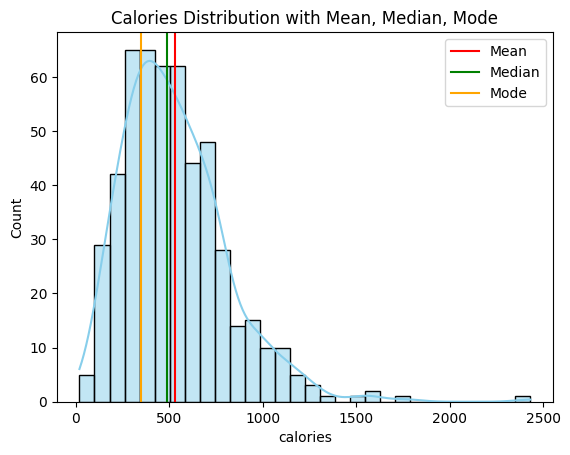

In [ ]:
plt.figure()
sns.histplot(df['calories'], kde=True, bins=30, color='skyblue')

plt.axvline(mean_calories, color='red', label='Mean')
plt.axvline(median_calories, color='green', label='Median')
plt.axvline(mode_calories, color='orange', label='Mode')

plt.title('Calories Distribution with Mean, Median, Mode')
plt.legend()
plt.show()

**Interpretation for Calories Distribution with Mean, Median, Mode:**

* **Shape** Right-skewed, peaking at lower calories.

* The **Mean** (531.11) > **Median** (490.0) > **Mode** (350) visually confirms this.

* **Outliers** Long right tail shows high-calorie items.

**Calories:Range**

In [ ]:
calories_summary= pd.DataFrame({
    'Min': df['calories'].min(),
    'Max': df['calories'].max()
}, index=['calories'])
print("MEASURE OF DISPERSION: RANGE \n",calories_summary)

MEASURE OF DISPERSION: RANGE 
           Min   Max
calories   20  2430


**Bar chart for Calories:Range**

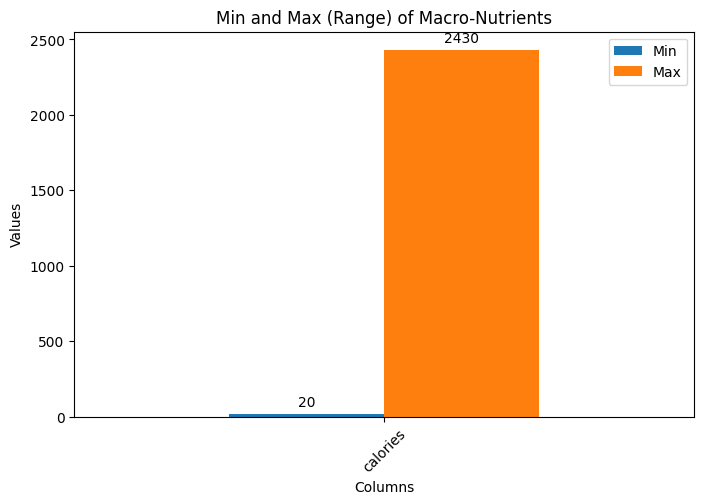

In [ ]:
ax = calories_summary.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)


plt.title('Min and Max (Range) of Macro-Nutrients')
plt.ylabel('Values')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.show()

**Interpretation for Calories: Range Bar Chart**

* **Min** 20 calories

* **Max** 2430 calories.

* Very wide range shows significant variability.

**Calories: Measure of Dispersion using Variance and Standard deviation**

In [ ]:
#Variance & std of Calories
variance_table = pd.DataFrame({'Variance': [df['calories'].var()]}, index=['calories'])
std_table = pd.DataFrame({'STD': [df['calories'].std()]}, index=['calories'])

# variance and standard deviation in a single table
dispersion_table = pd.concat([variance_table, std_table], axis=1)

print("Measure of Dispersion--Calories: Variance And Standard Deviation \n")
print(dispersion_table)

Measure of Dispersion--Calories: Variance And Standard Deviation 

              Variance         STD
calories  80032.552083  282.900251


**Interpretation for Calories Variance and Standard Deviation**

* **Variance**: 80032.55

*  **STD**: 282.90.

* High STD (282.90) indicates considerable spread of calorie values.

**Percentile Table:Calories**

In [ ]:
calories_percentiles = df['calories'].quantile([0.25, 0.50, 0.75])
calories_percentiles

,calories
0.25,330.0
0.50,490.0
0.75,690.0


**Calories:Box Plot Representing Percentile Distribution and Spread**

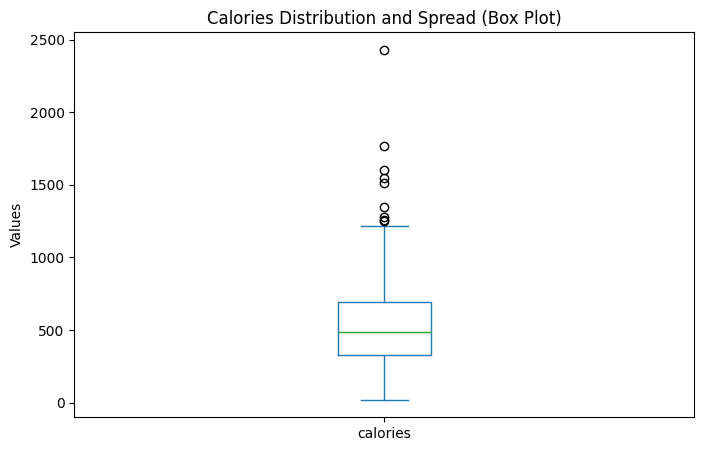

In [ ]:
df['calories'].plot(kind='box', figsize=(8,5))
plt.title('Calories Distribution and Spread (Box Plot)')
plt.ylabel('Values')
plt.show()

**Interpretation for Calories Box Plot  Percentile Distribution and Spread**

* **Q1**: 330.0

* **Median**: 490.0

* **Q3**: 690.0

* Most items are under 700 calories, but maximum (2430) points to extreme outliers.

* **Median**: ~490.0 calories. Many upper outliers are visible, indicating numerous exceptionally high-calorie items.

Overall the box plot Visually confirms right-skewed distribution with many calorie-dense items.

**Bar Chart of Deviation of Calories from the Mean**

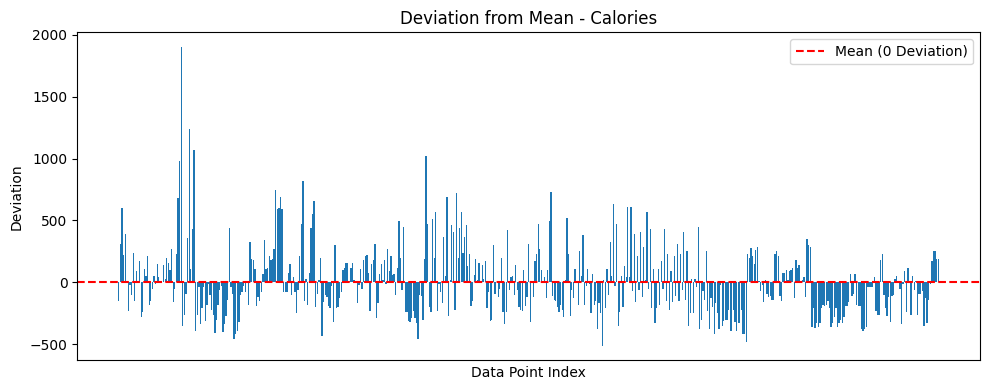

In [ ]:
# Calculate mean for calories
calorie_mean = df['calories'].mean()
# Deviation from mean calories
calorie_deviation = df['calories'] - calorie_mean
plt.figure(figsize=(10, 4))
plt.bar(range(len(calorie_deviation)), calorie_deviation)
plt.axhline(0, color='red', linestyle='--', label='Mean (0 Deviation)')
plt.title('Deviation from Mean - Calories')
plt.ylabel('Deviation')
plt.xlabel('Data Point Index')
plt.xticks([])
plt.legend()
plt.tight_layout()
plt.show()

**Interpretaion for  Deviation of Calories from the Mean**

* **Deviations** Numerous tall positive bars indicate many items significantly exceed the mean calorie count.

* Overall the deviation bar chart confirms high variability and many items far above average.

**Calories:Measure of Distribution using Skewness & Krutosis**

In [ ]:
#Skewness & Krutosis ofcalories
Skewness_table = pd.DataFrame({'Skewness': [df['calories'].skew()]}, index=['calories'])
Krutosis_table = pd.DataFrame({'Krutosis': [df['calories'].kurtosis()]}, index=['calories'])

# Skewness & Krutosis in a single table
distribution_table = pd.concat([Skewness_table, Krutosis_table], axis=1)

print("Measure of Distribution--Calories: Skewness & Krutosis \n")
print(distribution_table)

Measure of Distribution--Calories: Skewness & Krutosis 

          Skewness  Krutosis
calories  1.410725  4.695587


**Histplot of Calories: Measure of Distribution using Skewness**

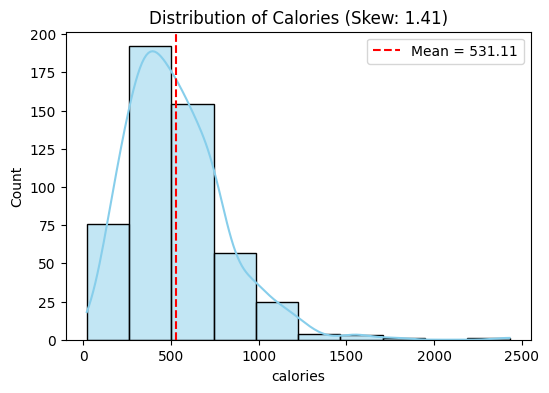

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['calories'], kde=True, bins=10, color='skyblue')

# Mean line
calorie_mean = df['calories'].mean()
plt.axvline(calorie_mean, color='red', linestyle='--', label=f'Mean = {calorie_mean:.2f}')

# Title with Skewness
skew_val = df['calories'].skew()
plt.title(f'Distribution of Calories (Skew: {skew_val:.2f})')

plt.xlabel('calories')
plt.ylabel('Count')
plt.legend(loc='upper right')
plt.show()

**Interpretaion for Histplot of Calories  using Skewness**

* **Skewness** 1.41.

* Moderately right-skewed, showing more lower-calorie items but a notable high-calorie tail.

**KDE/Density chart of Calories: Measure of Distribution using Krutosis**

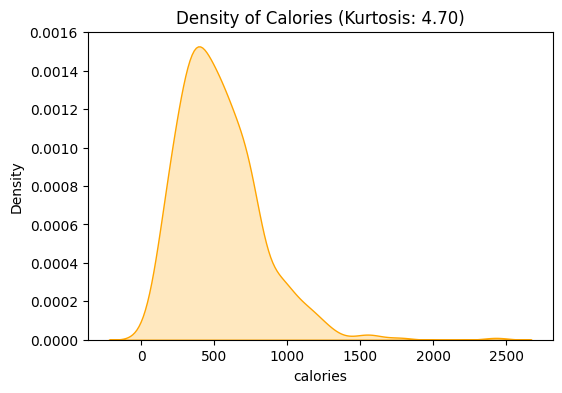

In [ ]:
plt.figure(figsize=(6,4))
sns.kdeplot(df['calories'], fill=True, color='orange')  # density plot only
kurt_val = df['calories'].kurt()

plt.title(f'Density of Calories (Kurtosis: {kurt_val:.2f})')
plt.xlabel('calories')
plt.ylabel('Density')
plt.show()

**Interpretation for KDE/Density of Calories using Kurtosis**

* **Kurtosis** 4.70.

*   Moderately leptokurtic, indicating a sharp peak at lower calories but also significant high-calorie outliers.


#**Visualizations**

#Univariate Analysis

**1.Distribution of Calories using Histplot**

---



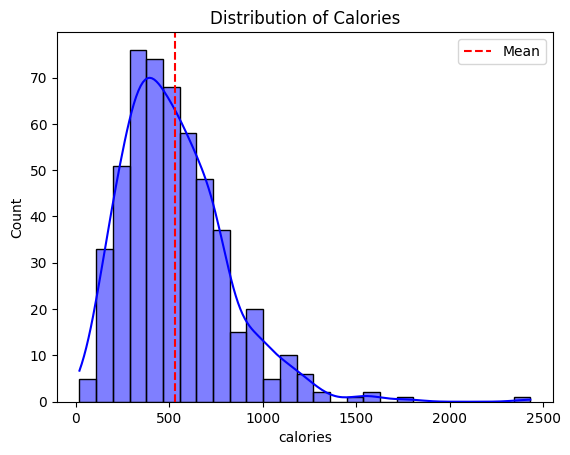

In [ ]:
sns.histplot(df['calories'], kde=True, color='blue')
plt.axvline(df['calories'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Distribution of Calories')
plt.legend()
plt.show()


**Technical Interpretation (Distribution Shape & Statistics)**

* The histogram shows a right-skewed distribution, with most food items having lower to moderate calorie values.

* A long right tail indicates the presence of several high-calorie outliers.

* The mean calorie line is influenced by these high-calorie items.

* Due to skewness, the median is more representative of a typical food item’s calorie content.

* The calorie values show a wide spread, ranging from low to extremely high values.


**Objective-Oriented Interpretation (Health & Nutrition Focus)**

*   Most junk food items fall within a moderate calorie range (approximately 200–700 calories).
*  A smaller but important group of items exceeds 1000 calories, indicating calorie-dense food and unhealthy options

*   These high-calorie items contribute significantly to daily energy intake.

*  Identifying such items is crucial for understanding potential health risks associated with frequent junk food consumption.


**Statistical Validation**

The positive skewness and higher mean observed statistically are visually confirmed by the right-skewed calorie distribution in the histogram.

**2.Distribution of Calorie Levels using Countplot**

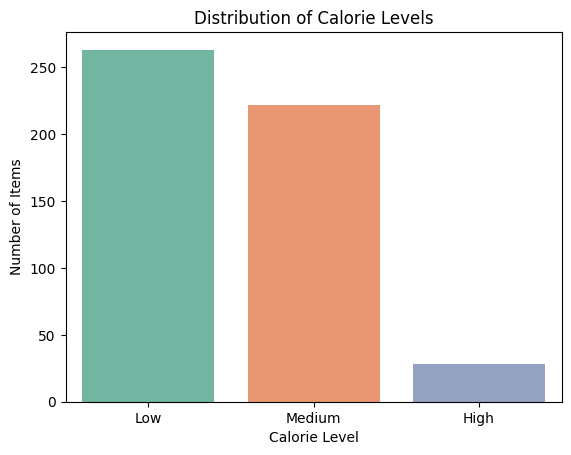

In [ ]:
sns.countplot(x='Calorie_Level', data=df, palette='Set2', hue='Calorie_Level', legend=False) #countplot for calorie level distribution
plt.title('Distribution of Calorie Levels')
plt.xlabel('Calorie Level')
plt.ylabel('Number of Items')
plt.show()

**Technical Interpretation (Counts & Distribution)**

*   The count plot shows the frequency of food items across calorie levels: Low, Medium, and High.
*  The distribution is uneven, indicating variation in calorie classification.
*   Low and Medium calorie levels have higher frequencies compared to High calorie level.
*  High calorie items form the smallest category in the dataset.


**Objective-Oriented Interpretation (Health & Nutrition Focus)**

*   A majority of junk food items fall under Low (263 items) and Medium (222 items) calorie categories.
*   This indicates that not all junk food items are extremely high in calories.
*  High calorie items (28 items), though fewer in number, are the most calorie-dense
*  Even a small number of high-calorie items can significantly impact daily calorie intake.
*  The visualization highlights calorie variability within junk food products, supporting informed dietary choices.



**Statistical Validation**

The statistical distribution of calorie values is reflected in the dominance of low and medium categories in the countplot.

**3.Distribution of Food Category (Veg / Non-Veg)**

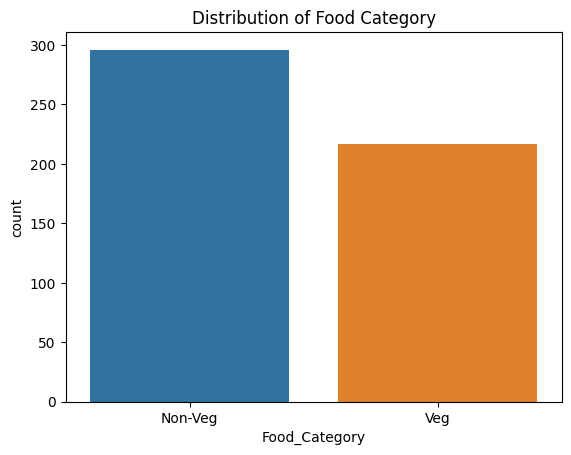

In [ ]:
sns.countplot(x='Food_Category', data=df, hue='Food_Category') #count plot for food category
plt.title('Distribution of Food Category')
plt.show()



**Technical Interpretation (Counts & Distribution)**
*  The count plot shows more Non-Veg items than Veg items in the dataset.
*  There are 296 Non-Veg and 217 Veg food items.
*  This indicates an uneven distribution across food categories.

**Objective-Oriented Interpretation (Health & Nutrition Focus)**
*   Nutritional insights are more influenced by Non-Veg food characteristics.
*   Veg food analysis is based on comparatively fewer data points.
*  Health-related conclusions should consider this category imbalance when interpreting results.

**Statistical Validation**

The frequency imbalance observed numerically is clearly represented in the categorical distribution of Veg and Non-Veg items.

**4.Pie Chart – Contribution of Key Micro-Nutritional Components**

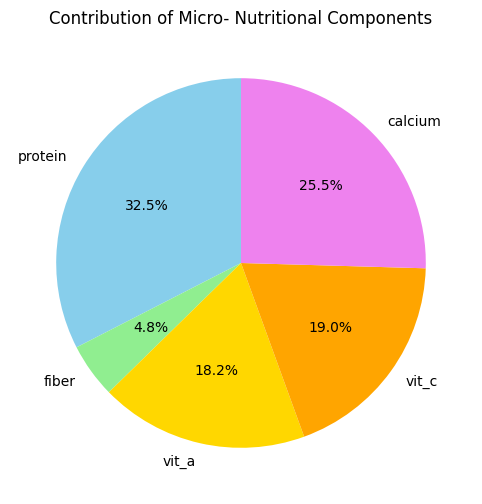

In [ ]:
micro_nutrient_columns = df[['protein', 'fiber', 'vit_a', 'vit_c', 'calcium']].sum()
plt.figure(figsize=(10, 6))
plt.pie(
    micro_nutrient_columns,
    labels=micro_nutrient_columns.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightgreen', 'gold', 'orange', 'violet']
)
plt.title('Contribution of Micro- Nutritional Components')
plt.show()


**Technical Interpretation (Proportions & Dominance)**

*   Slice size represents the relative total of each nutrient across the dataset.
*   Percentage labels enable quick comparison between nutrients.
*  Color coding helps clearly distinguish each micro-nutrient.

 **Objective-Oriented Interpretation (Health & Nutrition Focus)**

* Identifies which micro-nutrients are more prevalent in junk food items.
* Highlights lower presence of fiber and vitamins, indicating nutritional gaps
* Supports identification of nutritional patterns and imbalances.
* Contributes to understanding the overall micro-nutritional profile of junk food

**Statistical Validation**

The percentile and spread measures are visually supported by the proportional representation of micro-nutrient contributions.

**5.KDE / Density Plot for Sugar in junk food**

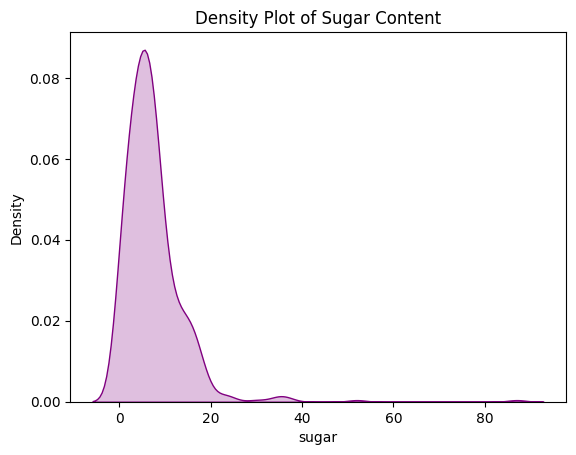

In [ ]:
sns.kdeplot(df['ugar'], fill=True, color='purple') #density plot for sugar in junk food
plt.title('Density Plot of Sugar Content')
plt.show()


**Technical Interpretation (Distribution Shape & Density)**


* The KDE plot shows a right-skewed distribution of sugar content.
* Most food items have low sugar levels, with a high density at lower values.
* A smooth density curve highlights variability in sugar content across products.


**Objective-Oriented Interpretation (Health & Nutrition Focus)**
* A subset of food items contains very high sugar levels, posing health concerns.
* High-sugar items, though fewer, can significantly impact dietary health.
* Junk food shows wide variation in sugar content, not uniformly high.
* Supports the objective of identifying patterns and variations in nutritional attribute

**Statistical Validation**

The positive skewness of sugar values is visually validated by the right-tailed density distribution.

#Bivariate Analysis

**1.Average Calories: Veg vs Non-Veg**



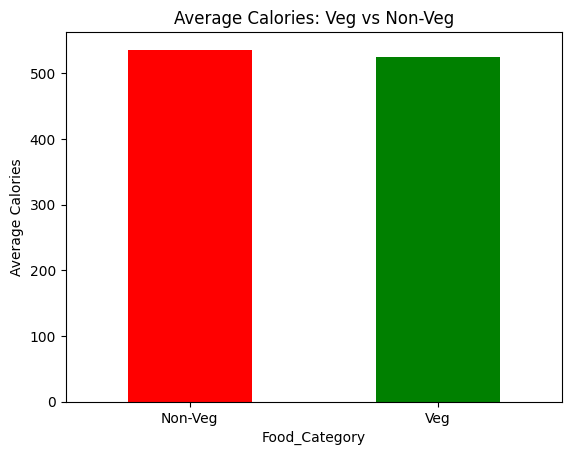

In [ ]:
df.groupby('Food_Category')['calories'].mean().plot(
    kind='bar', color=['red', 'green']
)
plt.title('Average Calories: Veg vs Non-Veg')
plt.ylabel('Average Calories')
plt.xticks(rotation=360) # Rotate x-axis labels
plt.show()

**Technical Interpretation (Comparison & Trends)**
*   The bar chart visually compares the average calorie content between Veg and Non-Veg food categories.
*   It shows a distinct difference, with Non-Veg items having a higher average calorie count than Veg items.
*   The use of different colors (green for Veg, orange for Non-Veg) clearly distinguishes the two categories.

**Objective-Oriented Interpretation (Health & Nutrition Focus)**
*   This chart indicates that, on average, Non-Veg junk food items tend to be more calorie-dense than Veg items.
*   This insight is crucial for consumers and health professionals looking to manage calorie intake from junk food.
*   It supports the objective of comparing nutritional values across product categories (Veg/Non-Veg) and helps identify general dietary patterns.
*   For individuals aiming to reduce calorie consumption, opting for Veg options might generally lead to lower calorie intake within this dataset.

**Statistical Validation**

The difference in mean calorie values between categories is directly reflected in the grouped bar comparison.

**High-Calorie Junk Food Items (≥1500 Calories)**

In [ ]:
high_calorie_items = df[df['calories'] >= 1500].sort_values(by='calories', ascending=False)
display(high_calorie_items[['restaurant', 'item', 'calories', 'Food_Category']])

,restaurant,item,calories,Food_Category
39,Mcdonalds,20 piece Buttermilk Crispy Chicken Tenders,2430,Non-Veg
44,Mcdonalds,40 piece Chicken McNuggets,1770,Non-Veg
47,Mcdonalds,10 piece Sweet N' Spicy Honey BBQ Glazed Tenders,1600,Veg
192,Burger King,American Brewhouse King,1550,Veg
38,Mcdonalds,12 piece Buttermilk Crispy Chicken Tenders,1510,Non-Veg


**2. Bar Chart of High-Calorie Food Items (>= 1500 Calories)**

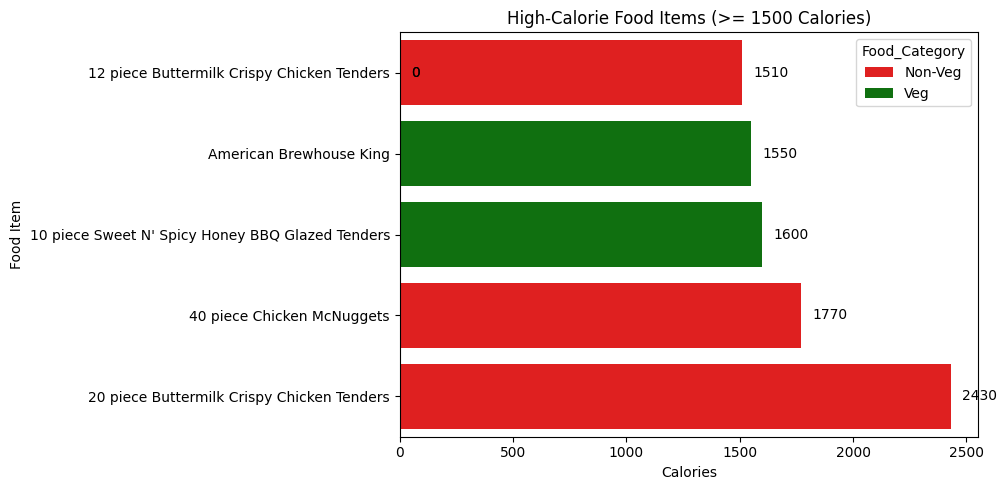

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='calories', y='item', hue='Food_Category', data=high_calorie_items.sort_values(by='calories', ascending=True),
                 palette={'Veg': 'green', 'Non-Veg': 'red'})
plt.title('High-Calorie Food Items (>= 1500 Calories)')
plt.xlabel('Calories')
plt.ylabel('Food Item')
plt.tight_layout()
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 50,
             p.get_y() + p.get_height() / 2,
             '{:1.0f}'.format(width),
             ha='left', va='center', fontsize=10)

plt.show()

**Technical Interpretation (High-Calorie Comparison)**
*  The bar chart displays food items with 1500+ calories, sorted in descending  order.
* Bar height represents the calorie value of each item.
* Color coding differentiates Veg and Non-Veg items for quick comparison.
* Rotated x-axis labels improve readability of item names.

**Objective-Oriented Interpretation (Nutritional Outliers)**
*  Clearly identifies extremely high-calorie junk food items.
*  Highlights foods that contribute most to excess calorie intake.
*   Shows that both Veg and Non-Veg categories contain high-calorie items.
*   Helps pinpoint calorie-dense products for health-focused analysis and decision-making.

**Statistical Validation**

The extreme range and high standard deviation observed statistically are confirmed by the presence of outlier high-calorie items.

**3.Average Calories by restaurant**

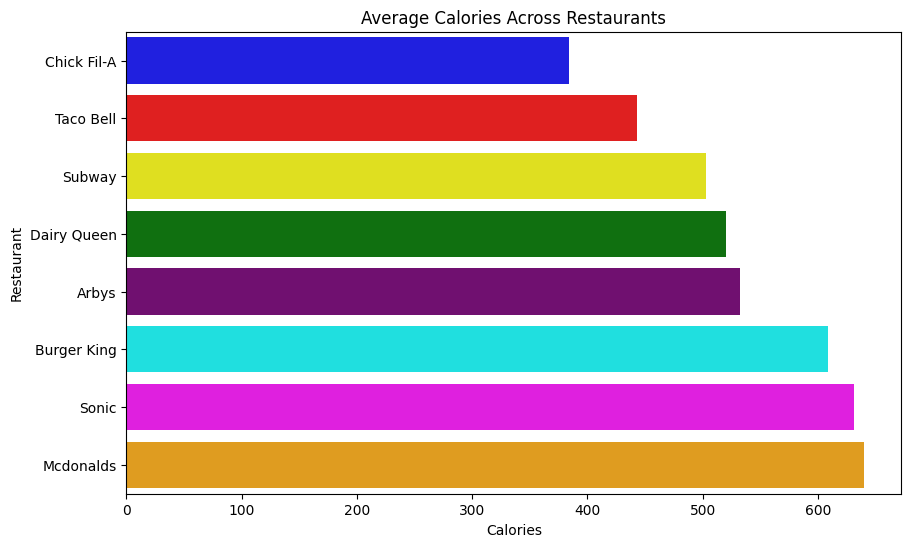

In [ ]:
shop_cal = df.groupby('restaurant')['calories'].mean().sort_values().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='calories', y='restaurant', data=shop_cal, hue='restaurant', palette=['blue', 'red', 'yellow', 'green', 'purple', 'cyan', 'magenta', 'orange'], legend=False) # Use custom palette
plt.title('Average Calories Across Restaurants')
plt.xlabel('Calories')
plt.ylabel('Restaurant')
plt.show()

**Technical Interpretation (Custom Colors & Comparison)**

* A horizontal bar chart is used to compare average calories across restaurants.
* Each restaurant is assigned a distinct custom color for clear differentiation.
* Restaurants are sorted by average calorie value, enabling easy ranking.
*  The x-axis represents Calories, and the y-axis lists Restaurant names.

**Objective-Oriented Interpretation (Nutrition & Shop Comparison)**

* Clearly compares average calorie levels across different fast-food shops.
* Helps identify restaurants offering lower vs higher calorie options.
* Supports health-focused decision-making for consumers and researchers
* Directly fulfills the objective of comparing nutritional values across shops.


**Statistical Validation**

The variability in calorie distribution is visually demonstrated through differing average values across restaurants.

**4.Sugar vs Calories & Fat vs Calories using sub-plots**

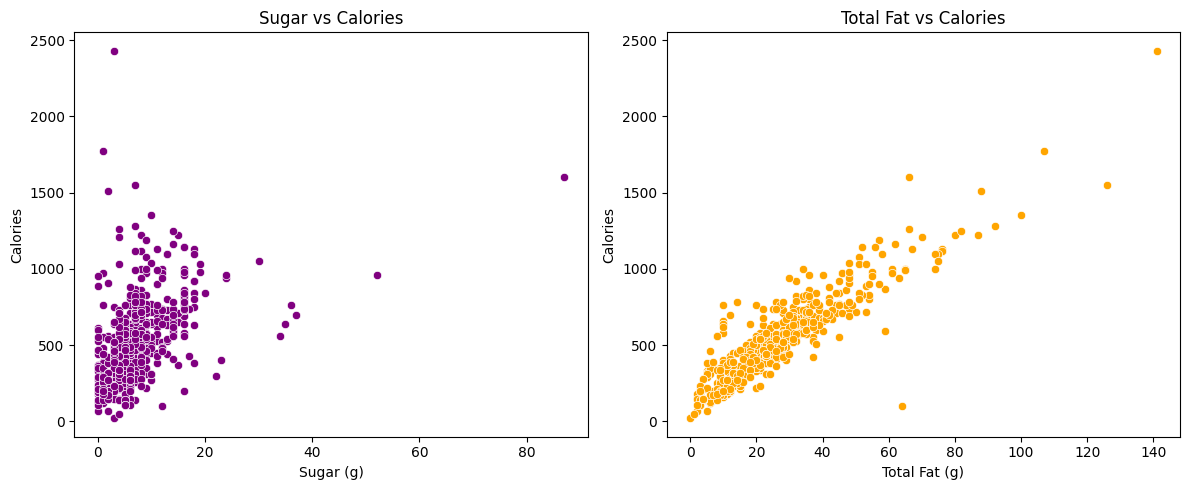

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sugar vs Calories
sns.scatterplot(
    x='sugar',
    y='calories',
    data=df,
    color='purple',
    ax=axes[0]
)
axes[0].set_title('Sugar vs Calories')
axes[0].set_xlabel('Sugar (g)')
axes[0].set_ylabel('Calories')

# Total Fat vs Calories
sns.scatterplot(
    x='total_fat',
    y='calories',
    data=df,
    color='orange',
    ax=axes[1]
)
axes[1].set_title('Total Fat vs Calories')
axes[1].set_xlabel('Total Fat (g)')
axes[1].set_ylabel('Calories')

plt.tight_layout()
plt.show()


**Technical Interpretation**

* The subplot compares the relationship of two key nutrients (sugar and total fat) with calories side by side.
* Both plots show a positive relationship with calories.
* The total fat vs calories plot shows a stronger and steeper trend than sugar.
* A few outliers indicate food items extremely high in calories due to high nutrient content.

**Objective-Oriented Interpretation**

* Demonstrates that both sugar and fat contribute to calorie density, but fat has a greater impact.
* Helps identify nutritionally risky junk foods with high calorie contribution.
* Enables comparison of different nutritional drivers of calories within a single view.

**Statistical Validation**

The correlation patterns indicated numerically are visually validated by the positive relationships in the scatter subplots.

**5.Bubble Plot for Protien vs Calories**

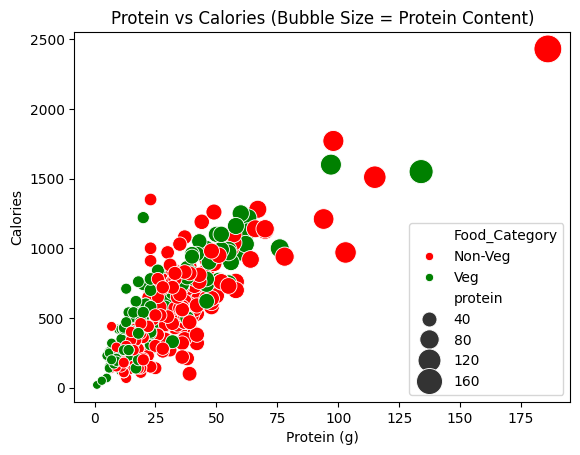

In [ ]:
sns.scatterplot(
    x='protein',
    y='calories',
    size='protein',
    hue='Food_Category',
    palette={'Veg': 'green', 'Non-Veg': 'red'},
    sizes=(40, 400),
    data=df
)
plt.title('Protein vs Calories (Bubble Size = Protein Content)')
plt.xlabel('Protein (g)')
plt.ylabel('Calories')
plt.show()


**Technical Interpretation (Relationship & Distribution)**

* Bubble size represents protein content, enabling multi-variable comparison.
* A general positive trend is observed: higher protein often corresponds to higher calories.
* Color coding differentiates Veg and Non-Veg food items.

**Objective-Oriented Interpretation (Health & Nutrition Focus)**

* Helps identify protein-rich junk food options and their calorie impact.
* Shows how protein–calorie patterns vary between Veg and Non-Veg foods.
* Supports assessment of nutritional density, not just calorie load.

**Statistical Validation**

The variation in protein contribution relative to calorie levels is visually supported by the bubble size distribution.



#Multivariate Analysis

**1.Heatmap Subplots (Micro & Macro Nutrients)**

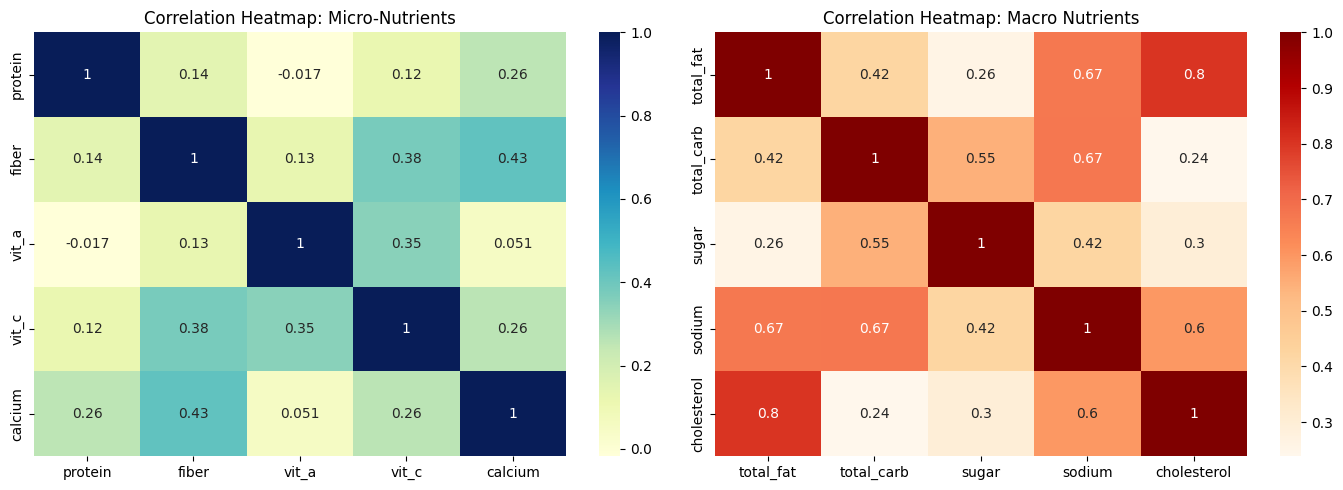

In [ ]:

# Micro-Nutrients
micro_cols = ['protein', 'fiber', 'vit_a', 'vit_c', 'calcium']
micro_data = df[micro_cols].corr()

# Macro-Nutrients
macro_cols = ['total_fat', 'total_carb', 'sugar', 'sodium', 'cholesterol']
macro_data = df[macro_cols].corr()

# Creation of Subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Micro-nutrients heatmap
sns.heatmap(
    micro_data,
    annot=True,
    cmap='YlGnBu',
    ax=axes[0]
)
axes[0].set_title('Correlation Heatmap: Micro-Nutrients')

# Macro-nutrients heatmap
sns.heatmap(
    macro_data,
    annot=True,
    cmap='OrRd',
    ax=axes[1]
)
axes[1].set_title('Correlation Heatmap: Macro Nutrients')

plt.tight_layout()
plt.show()


**Technical Interpretation**

*  Micro-nutrient heatmap shows weaker to moderate correlations, indicating varied nutritional presence.
*  Macro-nutrient heatmap shows stronger correlations, especially between fat, sugar, and cholesterol.

 **Objective-Oriented Interpretationt**

*  Highlights that macro nutrients are closely linked, contributing jointly to calorie density.
*  Micro-nutrients are less correlated, suggesting nutritional imbalance in junk food.
*   Supports identification of nutritional patterns and variations across nutrient types.
*   Helps distinguish energy-driving nutrients from health-supporting nutrients.

**Statistical Validation**

The statistical correlation measures are visually represented through intensity variations in the heatmap.

**2.Calories vs Micro vs Macro by Restaurant**

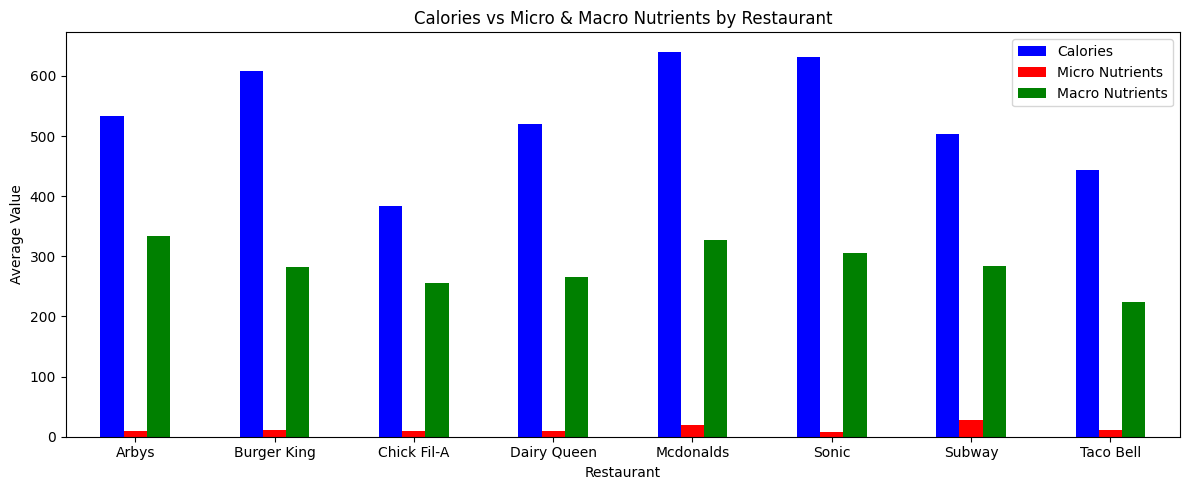

In [ ]:

# Average of key micro nutrients
df['Micro_Nutrients'] = df[['fiber', 'vit_a', 'vit_c', 'calcium']].mean(axis=1)

#Average of key macro nutrients
df['Macro_Nutrients'] = df[['total_fat', 'total_carb', 'sugar', 'sodium', 'cholesterol']].mean(axis=1)

# Grouping by restaurant
restaurant_summary = df.groupby('restaurant')[['calories', 'Micro_Nutrients', 'Macro_Nutrients']].mean()

#Grouped bar chart
restaurant_summary.plot(
    kind='bar',
    figsize=(12, 5),
    color=['Blue', 'red', 'green']
)
plt.title('Calories vs Micro & Macro Nutrients by Restaurant')
plt.xlabel('Restaurant')
plt.ylabel('Average Value')
plt.xticks(rotation=360)
plt.legend(['Calories', 'Micro Nutrients', 'Macro Nutrients'])
plt.tight_layout()
plt.show()


**Technical Interpretation**

* Micro and macro values are aggregated measures, enabling simplified comparison.
* Clear variation is observed in energy and nutrient profiles between restaurants

**Objective-Oriented Interpretation**

* Restaurants with higher calories often show higher macro-nutrient levels, indicating calorie-dense offerings.
* Micro-nutrient levels remain relatively low and similar across most restaurants
* Highlights the imbalance between energy intake and nutritional quality in junk food.
* Supports restaurant-wise nutritional comparison to identify healthier options.

**Statistical Validation**

The aggregated statistical differences across nutrients are visually reflected in the grouped multivariate comparison.

**3.Calorie Level Distribution by Restaurant and Food Category**

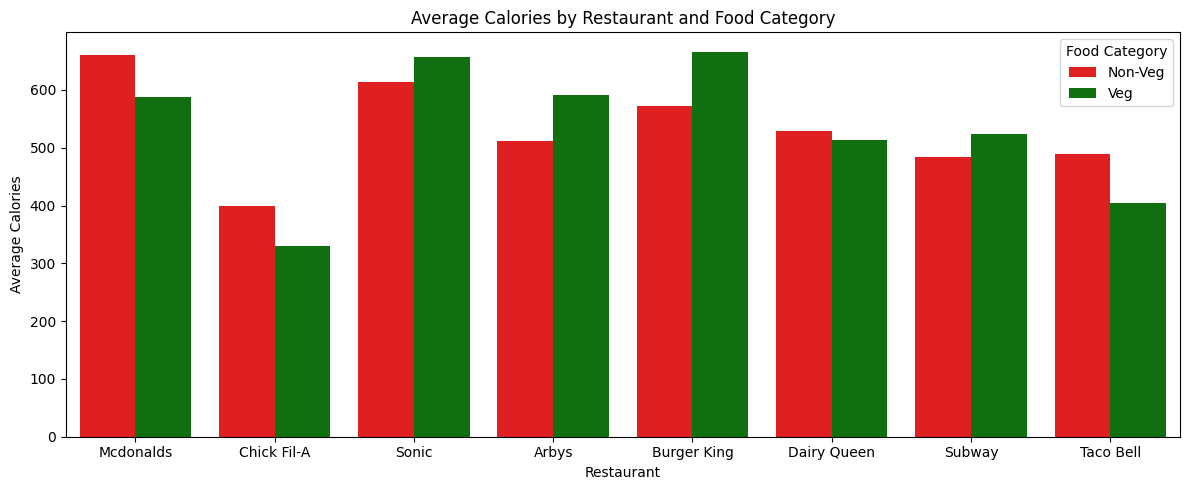

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(x='restaurant', y='calories', hue='Food_Category', data=df, palette={'Veg': 'green', 'Non-Veg': 'red'}, errorbar=None)
plt.title('Average Calories by Restaurant and Food Category')
plt.xlabel('Restaurant')
plt.ylabel('Average Calories')
plt.xticks(rotation=360, ha='center')
plt.legend(title='Food Category')
plt.tight_layout()
plt.show()

**Technical Interpretation**

* Uses grouped bars to compare average total fat for Veg and Non-Veg items by restaurant.
* Color coding (green for Veg, red for Non-Veg) enables easy category distinction.
*  Bar height represents average total fat content per restaurant and food category.
* Rotated x-axis labels improve readability of restaurant names.


 **Objective-Oriented Interpretationt**

*  Enables direct comparison of fat content between Veg and Non-Veg options across restaurants.
* Highlights restaurant-wise differences in average fat levels.
*   Shows that Non-Veg items generally have higher fat, with some Veg exceptions.
* Supports informed dietary choices and fulfills the objective of comparing nutritional values across shops and categories.

**Statistical Validation**

The statistical category proportions are validated through the  multivariate distribution plot

#Stage 4 – Documentation, Insights & Presentation

**Summary of Findings**

* This project analyzed the nutritional composition of junk food items across different restaurants.

* The analysis revealed significant variation in calorie content, macro-nutrients (fat, sugar, sodium), and micro-nutrients (fiber, vitamins, calcium)

* While most items fall within low to medium calorie ranges, several high-calorie outliers were identified.

*   Macro-nutrients showed strong positive relationships with calorie content, whereas micro-nutrients were relatively lower and less correlated.

* Restaurant-wise comparisons highlighted differences in nutritional profiles across brands

**Key Insights**

* Calories are positively skewed, indicating the presence of several extremely high-calorie junk food items.

* Fat and sugar are major contributors to calorie density, with strong positive relationships observed.

* Micro-nutrients such as fiber and vitamins are relatively low, highlighting nutritional imbalance.

* Nutritional composition varies significantly across restaurants, showing differing food quality patterns.

* Non-Veg items generally exhibit higher average fat and calorie values, though exceptions exist.


#**Types of Analysis Performed**


**Descriptive Analysis**

1.Central tendency (mean, median, mode)

2.Variance, standard deviation

3.Skewness and kurtosis

4.Distribution plots

**Purpose**: To summarize nutritional characteristics.

**Diagnostic Analysis**

1.Relationship analysis (Sugar vs Calories, Fat vs Calories)

2.Category comparison (Veg vs Non-Veg)

3.Restaurant-wise comparison

**Purpose**: To identify drivers of calorie density and nutritional imbalance.

**Predictive Analysis (Scope for Future Work)**

1.Correlation patterns between macro-nutrients and calories indicate strong predictive potential, suggesting that fat and sugar levels can help estimate calorie content.

2.These findings provide a foundation for developing regression models to predict calorie levels in future work.



**Prescriptive Analysis (Scope for Improvemen**t)

1.Based on findings, healthier menu recommendations can be suggested.

2.Nutritional reformulation strategies can be proposed for restaurants.


**Business-Based Recommendations**

**Menu Reformulation Strategy**
Restaurants should consider reducing excessive fat and sugar content in high-calorie items to improve nutritional balance while maintaining taste.

**Nutritional Transparency Enhancement**
Clear calorie labeling and nutrient breakdown should be prominently displayed to build consumer trust and regulatory compliance.

**Product Portfolio Diversification**
Introduce healthier alternatives with improved micro-nutrient profiles to attract health-conscious consumers.

**Data-Driven Menu Optimization**
Restaurants can leverage analytical insights to redesign menus based on nutritional performance and customer health trends.

**Competitive Benchmarking**
Restaurants with higher average calorie offerings may evaluate competitor strategies to optimize product positioning.

**Customer-Based Recommendations**

**Prefer Lower Fat and Sugar Options**
Consumers should select items with lower fat and sugar values to manage calorie intake effectively.

**Avoid Extreme High-Calorie Outliers**
Frequent consumption of high-calorie items identified in the analysis may increase health risks.

**Examine Nutritional Labels Carefully**
Understanding macro-nutrient composition helps make informed dietary decisions.

**Balance Diet with Micro-Nutrient Sources**
Since junk food is low in micro-nutrients, consumers should complement their diet with nutrient-rich foods.

**Moderation in Consumption**
Given the observed variability and calorie density, portion control and moderation are essential.

**Future Enhancements**

1.The analysis can be extended to include more restaurants and food categories to improve comparison across shops.

2.Additional micro-nutritional parameters can be included to better evaluate nutritional balance and unhealthy patterns.

3.A basic predictive model can be developed to estimate calorie levels based on macro-nutrient values.

4.The findings can be converted into an interactive dashboard to support easier decision-making and comparison.

5.Customer preference data can be integrated to analyze how nutritional patterns influence food choices.

6.Time-based data can be included to study trends in calorie and nutrient variation over time.

**Conclusion**

This project demonstrates how data analytics can effectively uncover nutritional patterns and variability in junk food items. The findings highlight calorie imbalance, macro-nutrient dominance, and cross-restaurant variation. The analysis supports informed decision-making and provides scope for further predictive modeling and dashboard integration.